# Typed Judgments

**TypeSafe's System One model as a pipeline stage — assertion gating on extracted edges, adjudication of
the entity-resolution review band, typing upstream of blocking, a must-not-merge test, and the judgments
carried into the graph as data.**

Every extractor in this repo is one of two shapes. GLiNER2.5 is a **span model**: it finds text and types
it, and everything it knows must be anchored in a span. The `claude` CLI is a **generative model**: it will
answer anything, in prose, and the work is constraining it back down to JSON. Both have a hole in the same
place — the small semantic judgments the pipeline needs *between* stages, which are neither spans nor
essays:

> is this extracted edge actually **asserted**, or hedged, denied, or conditional?
>
> are these two mentions the **same company**, or two companies with similar names?

[TypeSafe](https://docs.typesafe.ai) calls its model for this shape a **System One** model. You send
**state** — text, or a JSON object of named fields — and **typed questions**, and you get typed answers
with calibrated probabilities. Three question types, and that is the whole vocabulary:

| | asks | returns |
|---|---|---|
| **`Choice`** | which one of these options? | the label, `probabilities` over all labels, `confidence` |
| **`Noul`** | is this true? | a single probability of yes, 0–1 |
| **`Score`** | which level, on this described scale? | an expected position, `legend`, `probabilities`, `confidence` |

There is no text to parse and no schema to enforce, because **the answer set is the request**. That is a
different bargain from both other extractors, and it lands in the two places the pipeline explicitly leaves
open.

### Where it goes

| stage | the open question | what the repo does today | what this notebook does |
|---|---|---|---|
| **extract** | is this edge asserted or hedged? | GLiNER span-attribute pass, approximate | one `Choice` over four assertion statuses |
| **resolve** | are these two mentions the same entity? | `review_band()` — documented as *"the slot an LLM adjudicator fills"* | one `Score` over three levels + three diagnostic `Noul`s |
| **resolve, upstream** | is this ticker the company? | type-scoped blocking treats the extractor's label as a wall | one `Choice` over the ontology's types, read as a distribution |
| **graph** | which judgments become properties? | confidence and support | assertion status, per edge, filterable without re-running inference |

`src/kgx/typesafe.py` is the adapter: a disk-cached client with the same contract as `kgx.llm.ClaudeCLI`,
plus `judge_edges`, `adjudicate_pairs` and `apply_verdicts`.

### One break with the rest of the repo

**This notebook needs an API key.** `TYPESAFE_API_KEY`, from
[console.typesafe.ai](https://console.typesafe.ai/). No notebook before this one needs one: 03, 05, 06 and
07 use the `claude` CLI, and the rest use nothing hosted at all. This one needs a hosted API, and there is
no local fallback and no stub — a stub would make every measurement below meaningless.

What softens it is the same thing that softens the `claude` dependency: **every response is cached to disk**,
content-addressed on `(model, state, questions)`. A cache hit reconstructs a real `SystemOneResponse`, so
replayed and live code are the same code. A second run is free, byte-identical, and needs no key at all —
the outputs you are reading were produced by exactly such a run.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import msgspec
import pandas as pd
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 44)

import kgx
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, MODALITY_TRAPS, GOLD_DOC_FACTS
from kgx.data.shopping import (DOCUMENTS as SHOP_DOCS, ALIAS_GROUPS as SHOP_ALIASES,
                               DISTINCT_PAIRS)
from kgx.domains import SHOPPING

import kgx.typesafe as kts     # NOT exported from `kgx` -- importing it is a deliberate act

MATCH = MatchPolicy(normalize_names=True, use_aliases=True)

print(f"corpus   {len(DOCUMENTS)} documents, "
      f"{sum(len(d['text'].split()) for d in DOCUMENTS)} words")
print(f"gold     {len(GOLD_DOC_FACTS)} triples, {len(ALIAS_GROUPS)} alias groups, "
      f"{len(MODALITY_TRAPS)} modality traps")
print(f"matching {MATCH.label}")

corpus   10 documents, 2284 words
gold     47 triples, 13 alias groups, 11 modality traps
matching normalised + aliases


In [2]:
import typesafe_sdk

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print("typesafe-sdk", typesafe_sdk.__version__)
print(ts)

if ts.available:
    print("models:", ", ".join(ts.check()))
else:
    print("\nTYPESAFE_API_KEY is not set -- cached responses will replay, new ones will raise.")
    print(f"cached responses on disk: {len(list(ts.cache_dir.glob('*.json')))}")

def show(obj):
    """Print questions (or any msgspec-encodable object) exactly as they go on the wire."""
    print(json.dumps(json.loads(msgspec.json.encode(obj)), indent=2, ensure_ascii=False))

typesafe-sdk 0.6.0
CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=unset)

TYPESAFE_API_KEY is not set -- cached responses will replay, new ones will raise.
cached responses on disk: 351


---

## 1. What one request looks like

Three question types, one state, one request. Everything else in this notebook is this call with more
questions.

The state is a **JSON object with named fields**, not a blob. The docs are explicit that this is the
default choice, because each part of the context keeps a name the instructions can point at with a
backticked path — a question can say *does `body` state a price?* and mean one field, rather than
gesturing at three concatenated paragraphs.

In [3]:
from typesafe_sdk import Choice, Noul, Score

EVENT_KINDS = {
    "acquisition":   "One company is buying another, or part of another.",
    "earnings":      "Results, guidance, or a financial report.",
    "litigation":    "A lawsuit, investigation, or enforcement action.",
    "partnership":   "An alliance, joint venture, or supply agreement.",
    "other":         "None of the above.",
}
SETTLEDNESS = [
    "Speculative -- rumoured, or attributed to unnamed sources.",
    "Announced but conditional -- agreed, pending approval or closing.",
    "Completed -- it has happened.",
]

def probe_questions():
    return {
        "primary_event": Choice(instructions="What is the main corporate event `body` reports?",
                                criteria=EVENT_KINDS),
        "names_a_price": Noul(instructions="Does `body` state a transaction price or per-share "
                                           "consideration?"),
        "certainty": Score(instructions="How settled is the main event `body` reports?",
                           criteria=SETTLEDNESS),
    }

def probe_state(doc):
    return {"headline": doc["title"], "body": doc["text"][:900], "source": doc["source"]}

print("the request, as it goes on the wire:\n")
show({"model": ts.model, "state": {**probe_state(DOCUMENTS[0]), "body": "<first 900 chars of d01>"},
      "questions": probe_questions()})

the request, as it goes on the wire:

{
  "model": "jev-latest",
  "state": {
    "headline": "Northwind Logistics to Acquire Cascade Freight Systems in $1.4 Billion Transaction",
    "body": "<first 900 chars of d01>",
    "source": "Press Release"
  },
  "questions": {
    "primary_event": {
      "type": "choice",
      "criteria": {
        "acquisition": "One company is buying another, or part of another.",
        "earnings": "Results, guidance, or a financial report.",
        "litigation": "A lawsuit, investigation, or enforcement action.",
        "partnership": "An alliance, joint venture, or supply agreement.",
        "other": "None of the above."
      },
      "instructions": "What is the main corporate event `body` reports?"
    },
    "names_a_price": {
      "type": "noul",
      "instructions": "Does `body` state a transaction price or per-share consideration?"
    },
    "certainty": {
      "type": "score",
      "criteria": [
        "Speculative -- rumoured, or at

In [4]:
def report(doc, response):
    choice = response.choices["primary_event"]
    noul   = response.nouls["names_a_price"]
    score  = response.scores["certainty"]
    print(f"{doc['doc_id']}  {doc['title']}\n")
    print(f"primary_event   {choice.choice!r}   confidence {choice.confidence:.3f}")
    print("                " + "  ".join(f"{k}={v:.3f}" for k, v in
                                         sorted(choice.probabilities.items(), key=lambda kv: -kv[1])))
    print(f"names_a_price   {noul.noul:.3f}")
    print(f"certainty       {score.score:.3f}   confidence {score.confidence:.3f}")
    for level, p in sorted(score.probabilities.items()):
        print(f"                {level}  {p:.3f}  {score.legend[level]}")
    print(f"\nusage           {response.usage.input_tokens} in / {response.usage.output_tokens} out")

probe = ts.ask(probe_state(DOCUMENTS[0]), probe_questions())
report(DOCUMENTS[0], probe)

d01  Northwind Logistics to Acquire Cascade Freight Systems in $1.4 Billion Transaction

primary_event   'acquisition'   confidence 1.000
                acquisition=1.000  other=0.000  partnership=0.000  litigation=0.000  earnings=0.000
names_a_price   0.990
certainty       1.000   confidence 1.000
                0  0.000  Speculative -- rumoured, or attributed to unnamed sources.
                1  1.000  Announced but conditional -- agreed, pending approval or closing.
                2  0.000  Completed -- it has happened.

usage           723 in / 97 out


Every answer is typed and every probability is there to read, but this document is too easy to show what
the numbers are for. Ask the same three questions about a document that reports two things at once —
d06, a wire story about an antitrust inquiry *and* an ongoing price war.

In [5]:
probe6 = ts.ask(probe_state(DOCUMENTS[5]), probe_questions())
report(DOCUMENTS[5], probe6)

d06  EU opens antitrust inquiry into Halcyon as price war with Torrent intensifies

primary_event   'litigation'   confidence 1.000
                litigation=1.000  earnings=0.000  partnership=0.000  acquisition=0.000  other=0.000
names_a_price   0.050
certainty       1.410   confidence 0.120
                0  0.290  Speculative -- rumoured, or attributed to unnamed sources.
                1  0.010  Announced but conditional -- agreed, pending approval or closing.
                2  0.700  Completed -- it has happened.

usage           705 in / 96 out


Three things to take from those two outputs, because they set up everything below.

**The `Choice` returns a distribution, not a label.** `confidence` summarises how concentrated that
distribution is — and the docs are careful that it means *concentration*, not correctness and not
permission to act. Two genuinely acceptable options split the mass and drag confidence down without
anything being wrong.

**The `Noul` is one number.** There is no separate confidence, because a probability of yes already carries
it. 0.5 means *equally likely yes or no*, not *medium*. That distinction is why a yes/no question and a
graded question are different primitives rather than one with a flag.

**The `Score` is an expected value, and the d06 one is the reason to read `probabilities` as well.** On
d01 the mass sits on one level and the score *is* that level. On d06 it does not: the model puts most of
its weight on *completed* (the inquiry has opened) and a real minority on *speculative* (the price war is
reported second-hand), almost none in between — and the expected value lands at 1.41, on the one level
nobody believes. A `confidence` of 0.12 is the number that says so. An application that rounded the score
and threw away the rest would record the wrong answer with no sign it had done so; one that keeps the
distribution can see there are two readings and route accordingly. `legend` comes back with every score,
which is what lets a stored one be re-read months later.

---

## 2. Extraction — the judgment a span model cannot make

### 2.1 The baseline, unchanged

GLiNER2.5 over the ten `BUSINESS_NEWS` documents, exactly as notebook 01 runs it. Joint decoding, typed
endpoints enforced during decoding, no LLM.

In [6]:
t0 = time.perf_counter()
extractor = kgx.GlinerExtractor()
graphs = extractor.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS)
gliner_s = time.perf_counter() - t0

mentions = [m for g in graphs for m in g.mentions]
edges = [e for g in graphs for e in g.edges]
print(f"{len(mentions)} mentions, {len(edges)} edges from {len(graphs)} documents in {gliner_s:.1f}s")
print(f"ontology violations: {sum(len(g.validate(kgx.BUSINESS_NEWS)) for g in graphs)}")
print(f"infeasible documents: {sum(1 for g in graphs if not g.feasible)}")

display(pd.DataFrame([{"doc_id": g.doc_id, "words": len(g.text.split()),
                       "mentions": len(g.mentions), "edges": len(g.edges)} for g in graphs])
        .set_index("doc_id").T)

214 mentions, 170 edges from 10 documents in 14.1s
ontology violations: 0
infeasible documents: 0


doc_id,d01,d02,d03,d04,d05,d06,d07,d08,d09,d10
words,229,225,215,339,208,218,207,200,211,232
mentions,22,19,15,23,22,26,16,25,22,24
edges,35,8,5,17,22,15,12,37,10,9


### 2.2 The modality traps, asked directly

`kgx.data.documents.MODALITY_TRAPS` is eleven sentences planted in the corpus that have the **surface shape
of an asserted fact and are not one** — conditionals, denials, forecasts, a counterfactual, and one claim
attributed to an unnamed analyst. A pipeline with no modality pass asserts all eleven.

Before gating any edges, ask about the sentences on their own. State is the sentence; two questions, one
`Choice` over four statuses and one `Noul` that collapses them to the thing the graph actually needs.

**What is scored here and what is not.** Every one of the eleven is non-factual — that is why it is in the
list — so the `factual` Noul has a ground truth and is scored against it. The four-way status is *reported*
and not scored: the corpus's own `why` notes call several of these mixed ("negated expectation followed by a
hedged conditional reversal"), so there is no single gold label among my four to score them against.
Inventing one would be grading the model against my labelling, not against the corpus.

This section runs the `factual` question **twice**, because the first wording I wrote was wrong in an
instructive way. Here is that first wording, beside the `Choice` it is paired with.

In [7]:
NAIVE_FACTUAL = Noul(
    instructions="Can the main claim of `sentence` be recorded as a fact that currently holds?",
    criteria={
        "true":  "The sentence asserts it as true now or in the past.",
        "false": "The sentence denies it, conditions it, proposes it, or places it in the future.",
    },
)
first_attempt = {**kts.sentence_questions(), "factual": NAIVE_FACTUAL}
show(first_attempt)

{
  "status": {
    "type": "choice",
    "criteria": {
      "asserted": "The text states this relationship as a present or past fact. It holds, or it held.",
      "hypothetical": "The text raises this relationship only as a possibility, a condition, a proposal awaiting approval, or something that would happen if something else did. It is not claimed to have happened.",
      "negated": "The text denies this relationship, or states that it will not happen, is not planned, or is not expected.",
      "forward_looking": "The text projects, forecasts or guides that this relationship will hold in the future. It has not happened yet, but it is not merely conditional."
    },
    "instructions": "Does `sentence` assert its main claim as a fact, or does it hedge, deny, project or merely propose it? Judge the modality of the sentence, not whether the claim is plausible."
  },
  "factual": {
    "type": "noul",
    "instructions": "Can the main claim of `sentence` be recorded as a fact that c

In [8]:
def trap_table(rows):
    return pd.DataFrame([
        {"doc": t["doc_id"],
         "sentence": t["sentence"][:78] + "…",
         "status": r["status"],
         "conf": round(r["status_conf"], 2),
         "factual": round(r["factual"], 2),
         "caught": r["factual"] < 0.5,
         "why (corpus)": t["why"][:46]}
        for t, r in zip(MODALITY_TRAPS, rows)
    ])

traps_v1 = trap_table(kts.judge_sentences(ts, [t["sentence"] for t in MODALITY_TRAPS],
                                          questions=first_attempt))
display(traps_v1)

caught_v1 = int(traps_v1["caught"].sum())
print(f"caught {caught_v1}/{len(traps_v1)} planted traps  (factual < 0.5)")
print(f"mean factual probability: {traps_v1['factual'].mean():.3f}   max: {traps_v1['factual'].max():.3f}")
print("\nstatus distribution:")
print(traps_v1["status"].value_counts().to_string())

,doc,sentence,status,conf,factual,caught,why (corpus)
0,d01,"The proposed acquisition, if approved by...",hypothetical,1.00,0.02,True,hypothetical - conditional on regulatory...
1,d01,The Company does not expect to acquire a...,negated,0.84,0.20,True,negated expectation - no acquisition rel...
2,d02,Management has no plans to divest the Ca...,negated,0.93,0.66,False,negated intent - a divestiture is denied...
3,d03,We may face supply disruptions if tariff...,hypothetical,0.99,0.06,True,"mixed - the supplies(Torrent, Northwind)..."
4,d03,Should demand for expedited freight soft...,hypothetical,1.00,0.02,True,hypothetical - inverted conditional; no ...
5,d04,If tariffs on Asian-fabricated controlle...,hypothetical,1.00,0.03,True,counterfactual conditional - tariffs hav...
6,d05,The company said it has no plans to dive...,negated,0.86,0.71,False,"negated intent, reported speech - denies..."
7,d06,Duarte has acknowledged that the chipmak...,hypothetical,0.55,0.74,False,hypothetical plus explicit negation - no...
8,d07,The Company does not expect the SEC inqu...,negated,0.43,0.20,True,negated expectation followed by a hedged...
9,d09,One noted that if diesel remains above $...,hypothetical,1.00,0.05,True,"hypothetical, attributed to an unnamed a..."


caught 8/11 planted traps  (factual < 0.5)
mean factual probability: 0.266   max: 0.740

status distribution:
status
hypothetical    6
negated         5


A control matters here: a detector that answers "not factual" to everything scores 11/11 on a list of
eleven traps. So ask the same two questions about sentences from the same corpus that **are** plain
assertions, and check the two distributions actually separate.

In [9]:
CONTROLS = [
    "Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a "
    "definitive agreement to acquire Cascade Freight Systems for $1.4 billion in cash and stock.",
    "Cascade Freight Systems operates 41 cross-dock terminals across the Pacific Northwest "
    "and reported revenue of $612 million in fiscal 2025.",
    "Priya Raman is Chief Executive Officer of Northwind Logistics.",
    "A single vendor, Torrent Microsystems, supplies the controller boards used in "
    "substantially all of our telematics hardware.",
    "Halcyon Semiconductor Corporation operates fabrication sites in Phoenix, Dresden and Penang.",
]

def control_table(rows):
    return pd.DataFrame([
        {"sentence": s[:78] + "…", "status": r["status"],
         "conf": round(r["status_conf"], 2), "factual": round(r["factual"], 2),
         "asserted": r["factual"] >= 0.5}
        for s, r in zip(CONTROLS, rows)
    ])

controls_v1 = control_table(kts.judge_sentences(ts, CONTROLS, questions=first_attempt))
display(controls_v1)

def separation(traps, controls, label):
    print(f"{label}")
    print(f"  traps    mean factual {traps['factual'].mean():.3f}  "
          f"range [{traps['factual'].min():.2f}, {traps['factual'].max():.2f}]")
    print(f"  controls mean factual {controls['factual'].mean():.3f}  "
          f"range [{controls['factual'].min():.2f}, {controls['factual'].max():.2f}]")
    print(f"  separated: {controls['factual'].min() > traps['factual'].max()}")

separation(traps_v1, controls_v1, "first wording")

,sentence,status,conf,factual,asserted
0,Northwind Logistics Inc. (NASDAQ: NWL) t...,asserted,0.99,0.89,True
1,Cascade Freight Systems operates 41 cros...,asserted,1.00,0.81,True
2,Priya Raman is Chief Executive Officer o...,asserted,1.00,0.83,True
3,"A single vendor, Torrent Microsystems, s...",asserted,1.00,0.93,True
4,Halcyon Semiconductor Corporation operat...,asserted,1.00,0.83,True


first wording
  traps    mean factual 0.266  range [0.02, 0.74]
  controls mean factual 0.858  range [0.81, 0.93]
  separated: True


Separated, and 8 of 11. Now look at the three the `factual` Noul let through, against what the `Choice`
said about the same sentences in the same request.

In [10]:
missed = traps_v1[~traps_v1["caught"]]
display(missed[["doc", "sentence", "status", "conf", "factual", "why (corpus)"]])

print("on the sentences the Noul let through, the Choice called them:")
print(missed["status"].value_counts().to_string())
print(f"\nmean Choice confidence on those: {missed['conf'].mean():.2f}")

,doc,sentence,status,conf,factual,why (corpus)
2,d02,Management has no plans to divest the Ca...,negated,0.93,0.66,negated intent - a divestiture is denied...
6,d05,The company said it has no plans to dive...,negated,0.86,0.71,"negated intent, reported speech - denies..."
7,d06,Duarte has acknowledged that the chipmak...,hypothetical,0.55,0.74,hypothetical plus explicit negation - no...


on the sentences the Noul let through, the Choice called them:
status
negated         2
hypothetical    1

mean Choice confidence on those: 0.78


**The two questions disagree, and the `Choice` is right.** Every sentence the `factual` Noul let through is
a **denial**, and looking at one, the Noul is not wrong so much as answering a question I asked badly:

> *"Management has no plans to divest the Cascade brand."*

Can that be recorded as a fact that currently holds? **Yes.** It is a true statement about management's
plans. The claim I wanted judged was the divestiture; the claim the model judged was the sentence. For a
denial those are opposite polarities, and the instruction did not say which one to take.

Notice what the model did *not* do: it did not come back near 0.5. The three come back at 0.66, 0.71 and
0.74 — a confident answer to the reading I did not mean. That is the primitive working as designed. A Noul
near 0.5 means *equally likely yes or no*, not "your question was ambiguous", so ambiguity in the question
has to be removed from the question. It cannot be read off the answer.

The `Choice` never had this problem, because naming `negated` as a distinct outcome forces the distinction
the Noul collapsed. So the fix is to make the Noul name it too. `kts.sentence_questions()` now asks the
graph's question rather than the sentence's — *if a knowledge graph recorded this as a plain fact, would it
be correct?* — and says the trap out loud.

In [11]:
print("the current wording of `factual`:\n")
show({"factual": kts.sentence_questions()["factual"]})

the current wording of `factual`:

{
  "factual": {
    "type": "noul",
    "instructions": "If a knowledge graph recorded the relationship this sentence is about as a plain fact, would the graph be correct? Be careful with denials: a sentence saying something will NOT happen or is NOT planned does not make that thing a fact.",
    "criteria": {
      "true": "Yes: the sentence asserts the relationship as true now or in the past.",
      "false": "No: the sentence denies it, conditions it, proposes it, forecasts it, or only reports that someone said it might happen."
    }
  }
}


In [12]:
traps_v2 = trap_table(kts.judge_sentences(ts, [t["sentence"] for t in MODALITY_TRAPS]))
controls_v2 = control_table(kts.judge_sentences(ts, CONTROLS))

side_by_side = traps_v1[["doc", "sentence", "status"]].copy()
side_by_side["factual v1"] = traps_v1["factual"]
side_by_side["factual v2"] = traps_v2["factual"]
side_by_side["caught v1"] = traps_v1["caught"]
side_by_side["caught v2"] = traps_v2["caught"]
display(side_by_side)

caught = int(traps_v2["caught"].sum())
print(f"caught  v1 {caught_v1}/{len(traps_v1)}   ->   v2 {caught}/{len(traps_v2)}")
print(f"controls preserved  v1 {int(controls_v1['asserted'].sum())}/{len(CONTROLS)}   "
      f"->   v2 {int(controls_v2['asserted'].sum())}/{len(CONTROLS)}\n")
separation(traps_v1, controls_v1, "first wording")
separation(traps_v2, controls_v2, "current wording")

traps, controls = traps_v2, controls_v2       # what the rest of the notebook refers to

,doc,sentence,status,factual v1,factual v2,caught v1,caught v2
0,d01,"The proposed acquisition, if approved by...",hypothetical,0.02,0.06,True,True
1,d01,The Company does not expect to acquire a...,negated,0.20,0.09,True,True
2,d02,Management has no plans to divest the Ca...,negated,0.66,0.13,False,True
3,d03,We may face supply disruptions if tariff...,hypothetical,0.06,0.25,True,True
4,d03,Should demand for expedited freight soft...,hypothetical,0.02,0.05,True,True
5,d04,If tariffs on Asian-fabricated controlle...,hypothetical,0.03,0.07,True,True
6,d05,The company said it has no plans to dive...,negated,0.71,0.19,False,True
7,d06,Duarte has acknowledged that the chipmak...,hypothetical,0.74,0.15,False,True
8,d07,The Company does not expect the SEC inqu...,negated,0.20,0.11,True,True
9,d09,One noted that if diesel remains above $...,hypothetical,0.05,0.06,True,True


caught  v1 8/11   ->   v2 11/11
controls preserved  v1 5/5   ->   v2 5/5

first wording
  traps    mean factual 0.266  range [0.02, 0.74]
  controls mean factual 0.858  range [0.81, 0.93]
  separated: True
current wording
  traps    mean factual 0.116  range [0.05, 0.25]
  controls mean factual 0.918  range [0.88, 0.95]
  separated: True


**11 of 11, controls intact, and the gap between the two distributions opened from 0.07 to 0.63.** The three
denials went from 0.66, 0.71 and 0.74 to 0.13, 0.19 and 0.15 — and nothing that was already right got worse:
the trap mean fell from 0.266 to 0.116 and the control mean rose from 0.858 to 0.918. Same model, same
sentences, same `Choice` alongside in the same request. The only thing that changed is that the question now
says which reading of a denial to take.

Two cautions. A wording chosen because of three failures is a wording that fits three failures; the five
controls are the check against that, and they moved the right way. And the current wording is the one the
*rest* of the notebook uses — `traps` and `controls` from here on refer to it.

### 2.3 Gating the extracted edges

The traps are a diagnostic on hand-picked sentences. The pipeline question is different: of the **170 edges
GLiNER actually decoded**, which are asserted?

Two questions per edge, and they are deliberately not one question:

- **`supported`** (`Noul`) — does the document connect these two things *at all*, in any modality? This
  catches extraction errors: an edge between two entities the document never relates.
- **`status`** (`Choice`) — how does the document present the claim? This catches the modality traps: an
  edge the document really does discuss, and denies.

An edge that fails the first is a *different error* from one that fails the second, and one question cannot
tell them apart. §2.2 is also why `supported` is worded the way it is — it asks something with one reading
(*is this relationship discussed*) and leaves polarity to the `Choice`.

In [13]:
print("the two questions asked about one edge:\n")
show(kts.edge_questions(
    "Northwind Logistics", "acquires", "Cascade Freight Systems",
    relation_description=kgx.BUSINESS_NEWS.relation("acquires").description))

the two questions asked about one edge:

{
  "supported": {
    "type": "noul",
    "instructions": "Does the document say anything that bears on this claim: “Northwind Logistics” — acquires → “Cascade Freight Systems”? Here, “acquires” means: The head company is buying or has bought the tail. Answer yes if the document discusses this relationship at all, in any modality — asserted, denied, proposed or merely possible. Answer no if the document does not connect these two things.",
    "criteria": {
      "true": "The document addresses this relationship between these two specific things.",
      "false": "The document does not connect these two things, or one of them does not appear in it."
    }
  },
  "status": {
    "type": "choice",
    "criteria": {
      "asserted": "The text states this relationship as a present or past fact. It holds, or it held.",
      "hypothetical": "The text raises this relationship only as a possibility, a condition, a proposal awaiting approval, or somet

**How the questions are batched is the interesting part.** All questions in a request share one state and
are evaluated in parallel, and extra questions cost only their own tokens. So the unit of work is one
request per **document**, carrying two questions per candidate edge, with the whole document as the shared
state — not one request per edge.

Two consequences follow. The edge has to be *named in each question's instructions*, because the state is
shared and question ids are never sent to the model. And a document with more edges than one request should
carry is split: `max_questions=24` means twelve edges per request, so d03's five edges are one request and
d08's thirty-seven are four. Here is what one document's request looks like from the outside.

In [14]:
import math
EDGES_PER_REQUEST = 24 // 2

for doc_id in ("d03", "d08"):
    g = next(g for g in graphs if g.doc_id == doc_id)
    n = len([e for e in g.edges if not e.derived])
    ids = [f"e{i}_{q}" for i in range(n) for q in ("supported", "status")]
    print(f"{doc_id}: {n} edges -> {math.ceil(n / EDGES_PER_REQUEST)} request(s), "
          f"state = {{'document': <{len(g.text.split())} words>}}, {len(ids)} question ids")
    print("     " + ", ".join(ids[:EDGES_PER_REQUEST * 2]) + (" …" if len(ids) > EDGES_PER_REQUEST * 2 else ""))

d03: 5 edges -> 1 request(s), state = {'document': <215 words>}, 10 question ids
     e0_supported, e0_status, e1_supported, e1_status, e2_supported, e2_status, e3_supported, e3_status, e4_supported, e4_status
d08: 37 edges -> 4 request(s), state = {'document': <200 words>}, 74 question ids
     e0_supported, e0_status, e1_supported, e1_status, e2_supported, e2_status, e3_supported, e3_status, e4_supported, e4_status, e5_supported, e5_status, e6_supported, e6_status, e7_supported, e7_status, e8_supported, e8_status, e9_supported, e9_status, e10_supported, e10_status, e11_supported, e11_status …


In [15]:
t0 = time.perf_counter()
before = ts.n_calls + ts.n_cached
judgments = kts.judge_edges(ts, graphs, kgx.BUSINESS_NEWS, max_questions=24)
judge_s = time.perf_counter() - t0
n_requests = ts.n_calls + ts.n_cached - before

J = pd.DataFrame([j.as_record() for j in judgments])
print(f"{len(J)} edges judged in {judge_s:.1f}s: {n_requests} requests, "
      f"{2 * len(J) / n_requests:.1f} questions per request\n")
print(J["status"].value_counts().to_string())
print(f"\nkept (supported >= 0.5 and status == 'asserted'): {int(J['keep'].sum())} / {len(J)}")
display(J.sort_values("supported").head(12))

170 edges judged in 0.0s: 18 requests, 18.9 questions per request

status
asserted           120
negated             22
hypothetical        20
forward_looking      8

kept (supported >= 0.5 and status == 'asserted'): 114 / 170


,doc_id,head,relation,tail,gliner,supported,status,status_conf,keep
114,d08,Vantage Energy Partners,competes_with,Halcyon Semiconductor,0.311,0.07,negated,0.74,False
64,d04,Torrent Microsystems,subsidiary_of,Northwind Logistics,0.695,0.12,negated,0.66,False
169,d10,Northwind Logistics,subsidiary_of,Halcyon,0.873,0.13,negated,0.64,False
125,d08,Northwind Logistics,operates_in,Arizona,0.534,0.13,negated,0.20,False
50,d04,Northwind,acquires,Halcyon Semiconductor Corporation,0.702,0.14,negated,0.78,False
48,d04,Northwind Logistics,acquires,Halcyon Semiconductor Corporation,0.820,0.19,negated,0.81,False
122,d08,Northwind Logistics,operates_in,Arizona,0.518,0.23,negated,0.21,False
108,d07,Northwind Logistics Inc.,partners_with,SEC,0.744,0.27,negated,0.63,False
107,d07,Northwind Logistics Inc.,partners_with,SEC,0.903,0.28,negated,0.59,False
3,d01,Cascade Freight Systems,competes_with,Northwind Logistics,0.531,0.29,negated,0.54,False


The edges the gate drops, and why — the two failure modes side by side.

In [16]:
dropped = J[~J["keep"]]
unsupported = dropped[dropped["supported"] < 0.5]
hedged = dropped[(dropped["supported"] >= 0.5) & (dropped["status"] != "asserted")]

print(f"dropped {len(dropped)} of {len(J)}")
print(f"  {len(unsupported):3}  the document does not connect these two things (extraction error)")
print(f"  {len(hedged):3}  the document connects them but does not assert it (modality)\n")

for name, frame in [("NOT SUPPORTED", unsupported), ("NOT ASSERTED", hedged)]:
    print(f"── {name}")
    display(frame.sort_values("gliner", ascending=False)
                 .head(8)[["doc_id", "head", "relation", "tail", "gliner", "supported", "status"]])

dropped 56 of 170
   31  the document does not connect these two things (extraction error)
   25  the document connects them but does not assert it (modality)

── NOT SUPPORTED


,doc_id,head,relation,tail,gliner,supported,status
116,d08,Marcus Webb,officer_of,Vantage Energy Partners,0.962,0.33,negated
107,d07,Northwind Logistics Inc.,partners_with,SEC,0.903,0.28,negated
104,d07,Priya Raman,officer_of,Northwind Logistics Inc.,0.887,0.41,asserted
109,d07,Northwind Logistics Inc.,partners_with,SEC,0.878,0.30,negated
169,d10,Northwind Logistics,subsidiary_of,Halcyon,0.873,0.13,negated
105,d07,Marcus Webb,officer_of,Northwind Logistics Inc.,0.824,0.38,asserted
48,d04,Northwind Logistics,acquires,Halcyon Semiconductor Corporation,0.820,0.19,negated
106,d07,Northwind Logistics Inc.,partners_with,SEC,0.759,0.29,negated


── NOT ASSERTED


,doc_id,head,relation,tail,gliner,supported,status
93,d06,Halcyon,faces_risk,fines,0.961,0.98,hypothetical
92,d06,Halcyon,faces_risk,fines,0.955,0.98,hypothetical
90,d06,Halcyon,faces_risk,fines,0.953,0.98,hypothetical
89,d06,Halcyon,faces_risk,fines,0.946,0.98,hypothetical
0,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.943,0.99,hypothetical
1,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.928,0.99,hypothetical
43,d03,Northwind Logistics Inc.,faces_risk,supply disruptions,0.919,0.98,hypothetical
66,d05,Ana Duarte,officer_of,Halcyon Semiconductor Corporation,0.916,0.99,forward_looking


Note the `gliner` column on those rows. The extractor's own confidence is **not** the same signal: an edge
can be decoded at high confidence and still be one the document denies, because span-level confidence is
about the decoding, not about the claim. One picture of all 170 edges makes the point — GLiNER's
confidence on the x-axis, the `supported` probability on the y-axis, the `status` as colour.

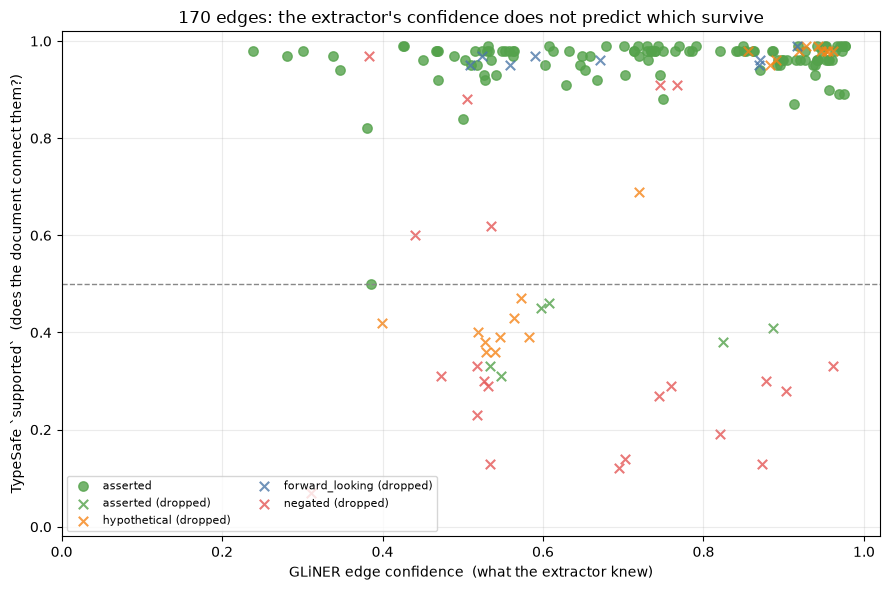

what the picture is saying:
  below the dashed line: the document never connects the two entities, at any GLiNER confidence
  above it, not green:   the document connects them and hedges or denies it -- often at GLiNER confidence > 0.9
  above it, green:       kept


In [17]:
import matplotlib.pyplot as plt

COLOUR = {"asserted": "#54A24B", "hypothetical": "#F58518",
          "forward_looking": "#4C78A8", "negated": "#E45756"}

fig, ax = plt.subplots(figsize=(9, 6))
for status, colour in COLOUR.items():
    for keep, marker in [(True, "o"), (False, "x")]:
        sub = J[(J["status"] == status) & (J["keep"] == keep)]
        if len(sub):
            ax.scatter(sub["gliner"], sub["supported"], marker=marker, c=colour, s=46, alpha=0.8,
                       label=f"{status}{'' if keep else ' (dropped)'}")
ax.axhline(0.5, color="#888", lw=1, ls="--")
ax.set_xlabel("GLiNER edge confidence  (what the extractor knew)")
ax.set_ylabel("TypeSafe `supported`  (does the document connect them?)")
ax.set_xlim(0, 1.02); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.25)
ax.set_title("170 edges: the extractor's confidence does not predict which survive")
ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

print("what the picture is saying:")
print("  below the dashed line: the document never connects the two entities, "
      "at any GLiNER confidence")
print("  above it, not green:   the document connects them and hedges or denies it -- "
      "often at GLiNER confidence > 0.9")
print("  above it, green:       kept")

### 2.4 Does gating help? Score both against the gold triples

`GOLD_DOC_FACTS` is 47 hand-written triples: what a perfect extractor and resolver should recover. Scoring
is `kgx.evaluate.score_triples` with the repo's standard alias-tolerant policy, so this is comparable with
notebooks 01, 03 and 07.

The prediction is made twice from **one** extraction pass and **one** inference pass — ungated, and gated.
Nothing else changes.

In [18]:
from kgx.extract import DocGraph

KEEP = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments if j.keep}

def gate(graphs, keep):
    """Rebuild the doc graphs with only the edges a judgment kept."""
    out = []
    for g in graphs:
        kept = [e for e in g.edges
                if (g.doc_id, g.mention(e.head).text, e.type, g.mention(e.tail).text) in keep]
        out.append(DocGraph(doc_id=g.doc_id, text=g.text, mentions=list(g.mentions),
                            edges=kept, feasible=g.feasible, meta=dict(g.meta)))
    return out

gated_graphs = gate(graphs, KEEP)
print(f"edges: {sum(len(g.edges) for g in graphs)} ungated -> "
      f"{sum(len(g.edges) for g in gated_graphs)} gated")

edges: 170 ungated -> 114 gated


In [19]:
resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

def triples_for(doc_graphs, **kw):
    kg = kgx.build_graph(doc_graphs, resolution, kgx.BUSINESS_NEWS)
    return kg, graph_triples(kg, **kw)

kg_ungated, tri_ungated = triples_for(graphs)
kg_gated,   tri_gated   = triples_for(gated_graphs)

scores = {
    "GLiNER2.5, ungated":        score_triples(tri_ungated, GOLD_DOC_FACTS, policy=MATCH,
                                               aliases=ALIAS_GROUPS),
    "+ TypeSafe assertion gate": score_triples(tri_gated, GOLD_DOC_FACTS, policy=MATCH,
                                               aliases=ALIAS_GROUPS),
}
display(comparison_table(scores))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
+ TypeSafe assertion gate,normalised + aliases,47,47,19,0.404,0.404,0.404
"GLiNER2.5, ungated",normalised + aliases,68,47,19,0.279,0.404,0.330


A gate can only ever *remove* triples, so recall cannot rise and precision can. Whether that is a good
trade depends on what the graph is for — and the honest way to show it is not one row but the whole
frontier, which the next cell draws by sweeping the `supported` threshold under three status policies. All
of it comes from the same single inference pass: **changing a threshold re-reads stored judgments, it does
not re-ask the model.**

best F1 0.409 at supported >= 0.6, asserted only
(inference cost of this entire sweep: 0 new requests)


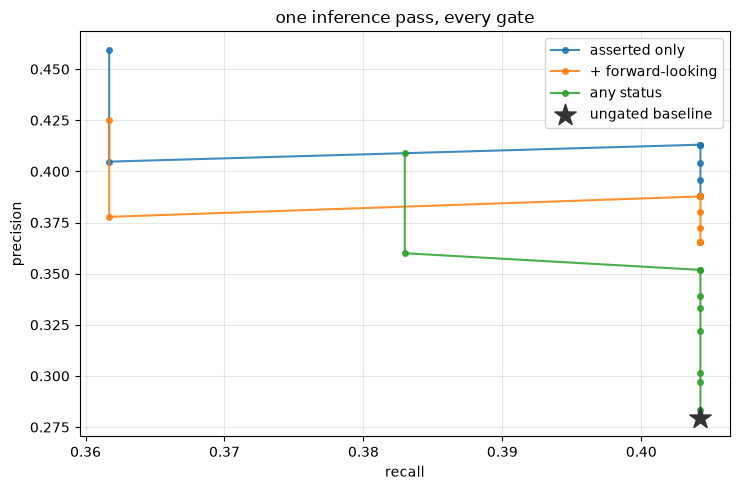

statuses,asserted only,+ forward-looking,any status
supported >=,,,
0.00,0.396,0.384,0.330
0.10,0.396,0.384,0.333
0.20,0.396,0.384,0.342
0.30,0.396,0.384,0.345
0.40,0.400,0.388,0.358
0.50,0.404,0.392,0.365
0.60,0.409,0.396,0.369
0.70,0.409,0.396,0.376
0.80,0.409,0.396,0.376


In [20]:
sweep = []
for tau in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    for statuses, label in [(kts.ASSERTED, "asserted only"),
                            (frozenset({"asserted", "forward_looking"}), "+ forward-looking"),
                            (frozenset(kts.ASSERTION_LEVELS), "any status")]:
        keep = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments
                if j.supported >= tau and j.status in statuses}
        _, tri = triples_for(gate(graphs, keep))
        s = score_triples(tri, GOLD_DOC_FACTS, policy=MATCH, aliases=ALIAS_GROUPS)
        sweep.append({"supported >=": tau, "statuses": label, "triples": len(tri),
                      "precision": s.precision, "recall": s.recall, "f1": s.f1})

S = pd.DataFrame(sweep)
best = S.loc[S["f1"].idxmax()]
print(f"best F1 {best['f1']:.3f} at supported >= {best['supported >=']}, {best['statuses']}")
print(f"(inference cost of this entire sweep: {ts.n_calls} new requests)")

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, grp in S.groupby("statuses", sort=False):
    ax.plot(grp["recall"], grp["precision"], "o-", label=label, alpha=0.85, markersize=4)
u = scores["GLiNER2.5, ungated"]
ax.scatter([u.recall], [u.precision], marker="*", s=260, color="#333", zorder=5,
           label="ungated baseline")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.grid(alpha=0.3)
ax.set_title("one inference pass, every gate")
ax.legend(); plt.tight_layout(); plt.show()

display(S.pivot_table(index="supported >=", columns="statuses", values="f1", sort=False).round(3))

Read the table's corners, because they say something the headline number hides.

In [21]:
def f1_at(tau, label):
    return float(S[(S["supported >="] == tau) & (S["statuses"] == label)]["f1"].iloc[0])

print(f"no gate at all                          F1 {f1_at(0.0, 'any status'):.3f}")
print(f"`status` alone   (asserted, tau = 0)    F1 {f1_at(0.0, 'asserted only'):.3f}")
print(f"`supported` alone (any status, tau = .8) F1 {f1_at(0.8, 'any status'):.3f}")
print(f"`supported` alone (any status, tau = .95) F1 {f1_at(0.95, 'any status'):.3f}")
print(f"both             (asserted, tau = .6)   F1 {f1_at(0.6, 'asserted only'):.3f}")

no gate at all                          F1 0.330
`status` alone   (asserted, tau = 0)    F1 0.396
`supported` alone (any status, tau = .8) F1 0.376
`supported` alone (any status, tau = .95) F1 0.396
both             (asserted, tau = .6)   F1 0.409


**Either question alone gets most of the way; together they add a little.** That is not a contradiction of
§2.3 — the two questions do catch different edges, the 31/25 split is real — it is a statement about
correlation: when the document does not connect two things, the model tends to call the claim `negated`
too, and vice versa. So for the *decision* the signals are largely redundant, while for the *diagnosis* they
are not. Which is exactly the argument for keeping both as data rather than collapsing them into one
boolean at the point of decision: the boolean would score about the same, and the reason for every drop
would be gone.

---

## 3. Resolution — the review band, adjudicated

### 3.1 The baseline, and pair completeness

`kgx.EntityResolver` is the repo's hand-rolled pipeline: normalise → block → score → cluster →
canonicalise. Scored B-cubed against the 13 gold alias groups, it lands where notebooks 01 and 05 say it
does — **precision 1.000, recall short of it.** Every point of headroom is in recall.

`pair_completeness` is the number to watch beside it: the fraction of gold-same pairs blocking ever
*proposed*. A pair blocking never generated cannot be adjudicated, only missed — which is the finding
notebook 05 lands on, that the wins come from candidate generation rather than from better scoring.

It is **not** an upper bound on B-cubed recall, and the two numbers below make that concrete by crossing.
Clustering is transitive: if `Northwind Logistics Inc.`–`Northwind Logistics` and
`Northwind Logistics`–`Northwind` are both candidates, the third pair is united without ever being
proposed. So pair completeness bounds what the *adjudicator* can see, not what the clustering can reach.

In [22]:
GOLD = {}
for canon, aliases in ALIAS_GROUPS.items():
    surfaces = {a.strip() for a in aliases}
    for m in mentions:
        if m.text.strip() in surfaces:
            GOLD[m.mention_id] = canon

MENTION = {m.mention_id: m for m in mentions}

base = kgx.bcubed(resolution.mention_to_canon, GOLD)
blocking = resolver.blocking_report(mentions, GOLD)

print(f"{len(resolution.entities)} canonical entities from {len(mentions)} mentions, "
      f"{len(GOLD)} gold-labelled")
print(f"B-cubed   precision {base['precision']:.4f}   recall {base['recall']:.4f}   "
      f"F1 {base['f1']:.4f}   (n={base['n']})")
print(f"blocking  pair completeness {blocking['pair_completeness']:.4f}  "
      f"({int(blocking['gold_pairs'])} gold pairs, {int(blocking['candidate_pairs'])} candidates "
      f"from {int(blocking['all_pairs'])} possible)")

109 canonical entities from 214 mentions, 77 gold-labelled
B-cubed   precision 1.0000   recall 0.8972   F1 0.9458   (n=77)
blocking  pair completeness 0.8791  (339 gold pairs, 1462 candidates from 22791 possible)


### 3.2 What is in the review band

`Resolution.review_band(low)` returns pairs blocking proposed and scoring placed **below the merge
threshold but above `low`** — too close to call. The repo's docstring calls this "the slot an LLM
adjudicator fills"; notebook 05 filled it with Claude.

It is not an arbitrary band, and 0.880 is not an arbitrary number. `kgx.resolve` scores a bare
organisation-name prefix match — `Northwind` inside `Northwind Logistics Inc.` — at **0.88**, and lifts it
to 0.92, over the 0.9 threshold, only when the two mentions' contexts agree. The README states the reason:

> *A prefix match is not an identity.* `Northwind` / `Northwind Logistics` should merge; `Apple` /
> `Apple Bank` should not, and the string evidence is identical.

So every prefix pair whose contexts did not corroborate lands at exactly 0.880 — proposed, scored, and
held. Which is the correct thing for a string metric to do, and leaves a decision that needs world
knowledge sitting in a queue.

In [23]:
BAND_LOW = 0.70
band = resolution.review_band(low=BAND_LOW)

def gold_verdict(p):
    ga, gb = GOLD.get(p.a), GOLD.get(p.b)
    if ga is None or gb is None:
        return "unlabelled"
    return "same" if ga == gb else "different"

B = pd.DataFrame([{"a": MENTION[p.a].text, "b": MENTION[p.b].text, "type": p.type,
                   "resolver": round(p.score, 3), "block": p.block, "gold": gold_verdict(p)}
                  for p in band])
print(f"{len(band)} pairs in the band [{BAND_LOW}, {resolution.threshold})\n")
print(B["gold"].value_counts().to_string())
print()
display(B.drop_duplicates(subset=["a", "b", "type"]).head(20))

55 pairs in the band [0.7, 0.9)

gold
same          34
unlabelled    21



,a,b,type,resolver,block,gold
0,Northwind Logistics Inc.,Northwind,company,0.880,head,same
1,Northwind Logistics,Northwind,company,0.880,head,same
4,Northwind,Northwind Logistics,company,0.880,head,same
5,Northwind,Northwind Logistics Inc.,company,0.880,head,same
11,Halcyon Semiconductor Corporation,Halcyon,company,0.880,head,same
22,Halcyon Semiconductor,Halcyon,company,0.880,head,same
26,Halcyon,Halcyon Semiconductor,company,0.880,head,same
34,Adjusted operating margin,operating margin,financial_metric,0.844,tail,unlabelled
35,adjusted operating margin,operating margin,financial_metric,0.837,tail,unlabelled
36,gross margin,non-GAAP gross margin,financial_metric,0.835,tail,unlabelled


### 3.3 The question, and the state it is asked about

This is TypeSafe's own
[entity-alignment cookbook](https://docs.typesafe.ai/cookbooks/entity_alignment.md), moved from beer
catalogues to company mentions. The shape it recommends is worth stating on its own, because it is not the
obvious one:

**one `Score` whose levels *are* the outcomes**, instead of a probability plus two fitted thresholds.

```
0  different entities          ->  leave unlinked
1  related, may be the same    ->  curator queue
2  the same entity             ->  merge
```

The decision rule is then `round(score)` — there is nothing to tune, and the middle level is not a hedge,
it is the review queue the repo already has a name for. Three diagnostic `Noul`s ride along in the same
request: they do not feed the decision, they make a disagreement with the resolver **attributable** rather
than mysterious.

In [24]:
show(kts.pair_questions("company"))

{
  "link_state": {
    "type": "score",
    "criteria": [
      "They refer to two different real-world entities.",
      "They refer to closely related entities that may or may not be the same one.",
      "They refer to one and the same real-world entity."
    ],
    "instructions": "`mention_a` and `mention_b` are two mentions of a company, each quoted with the surrounding sentence it appeared in. How do they relate?"
  },
  "same_name": {
    "type": "noul",
    "instructions": "Ignoring abbreviations, legal suffixes, honorifics and possessives, do `mention_a.text` and `mention_b.text` name the same thing?"
  },
  "same_context": {
    "type": "noul",
    "instructions": "Do `mention_a.context` and `mention_b.context` describe the same entity doing the same kind of thing, rather than two different entities that happen to share part of a name?"
  },
  "abbreviation": {
    "type": "noul",
    "instructions": "Is one of `mention_a.text` and `mention_b.text` an abbreviation, acronym,

And the state. Each mention goes in with its **context window**, not just its surface string — that is the
whole game, because `Apple` and `Apple Bank` are inseparable as strings and separable in context, and
`kgx.extract.Mention` already carries the window for exactly this reason. Named fields, so the questions
above can point at `mention_a.text` and `mention_b.context` by path. Here is the first pair in the band as
the model sees it.

In [25]:
first = next(p for p in band if MENTION[p.a].text != MENTION[p.b].text)
show(kts.pair_state(MENTION[first.a], MENTION[first.b]))
print(f"\nresolver score {first.score:.3f} via the {first.block!r} blocker; gold says {gold_verdict(first)}")

{
  "mention_a": {
    "text": "Northwind Logistics Inc.",
    "type": "company",
    "context": "SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreement to acquire"
  },
  "mention_b": {
    "text": "Northwind",
    "type": "company",
    "context": "l participants are in listen-only mode. Priya Raman, Chief Executive Officer: Thank you. Northwind delivered full year revenue of $2.41 billion, up 6.4% year over year, with fourth quarter"
  }
}

resolver score 0.880 via the 'head' blocker; gold says same


In [26]:
t0 = time.perf_counter()
before_calls, before_cached = ts.n_calls, ts.n_cached
verdicts = kts.adjudicate_pairs(ts, band, MENTION)
adj_s = time.perf_counter() - t0

V = pd.DataFrame([v.as_record() for v in verdicts])
V["gold"] = [gold_verdict(p) for p in band]

print(f"{len(verdicts)} pairs adjudicated in {adj_s:.1f}s "
      f"({ts.n_calls - before_calls} live, {ts.n_cached - before_cached} replayed)\n")
print(pd.crosstab(V["outcome"], V["gold"]).to_string())
display(V.sort_values("level", ascending=False).head(12))

55 pairs adjudicated in 0.0s (0 live, 55 replayed)

gold     same  unlabelled
outcome                  
merge      28          10
reject      0           3
review      6           8


,a,b,type,resolver,level,conf,same_name,same_context,abbrev,outcome,gold
25,Halcyon Semiconductor,Halcyon,company,0.880,1.99,0.99,0.87,0.96,0.93,merge,same
20,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.99,0.99,0.86,0.91,0.94,merge,same
21,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.98,0.96,0.71,0.86,0.90,merge,same
46,Telematics unit,Telematics,business_segment,0.734,1.98,0.96,0.86,0.78,0.79,merge,unlabelled
39,"Phoenix, Arizona",Phoenix,geography,0.778,1.97,0.96,0.83,0.92,0.85,merge,unlabelled
16,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.96,0.94,0.88,0.61,0.94,merge,same
17,Halcyon Semiconductor Corporation,Halcyon,company,0.880,1.96,0.93,0.85,0.61,0.94,merge,same
33,Halcyon Semiconductor,Halcyon,company,0.880,1.96,0.94,0.61,0.82,0.90,merge,same
3,Northwind Logistics Inc.,Northwind,company,0.880,1.96,0.94,0.81,0.76,0.93,merge,same
41,"Phoenix, Arizona",Phoenix,geography,0.755,1.95,0.93,0.86,0.75,0.84,merge,unlabelled


### 3.4 Apply the merges, and re-score

`apply_verdicts` folds accepted merges into the resolver's clustering by union-find and returns a fresh
`mention_id -> canon_id` map. It does not mutate the `Resolution`, so the before/after comparison stays
runnable in either order.

Transitivity is the point and the risk in the same mechanism: three pairwise merges can produce one cluster
that no single verdict proposed. So look at what changed before looking at the score.

In [27]:
from collections import defaultdict

merged = kts.apply_verdicts(resolution, verdicts)                          # merge only
merged_loose = kts.apply_verdicts(resolution, verdicts, accept=("merge", "review"))

after = defaultdict(list)
for mid, cid in merged.items():
    after[cid].append(mid)

changed = []
for cid, members in after.items():
    origins = {resolution.mention_to_canon[m] for m in members}
    if len(origins) > 1:
        changed.append({"merged cluster": cid, "mentions": len(members),
                        "was": len(origins),
                        "surfaces": ", ".join(sorted({MENTION[m].text for m in members}))[:96]})
display(pd.DataFrame(changed).sort_values("mentions", ascending=False))

oversized = [c for c, m in after.items() if len(m) > 15]
print(f"clusters over 15 mentions after merging: {len(oversized)}")
for c in oversized:
    print(f"  {c}: {len(after[c])} mentions, "
          f"{len(sorted({MENTION[m].text for m in after[c]}))} distinct surfaces -- "
          f"{'fine: one company across ten documents' if c.startswith('company:') else 'check'}")

,merged cluster,mentions,was,surfaces
3,geography:phoenix,7,2,"PHOENIX, Phoenix, Phoenix, Arizona"
0,sector:freight,6,2,"Freight, freight, freight brokerage"
1,business_segment:telematics,4,2,"Telematics, Telematics unit, telematics ..."
2,financial_metric:adjusted-operating-margin,3,2,"Adjusted operating margin, adjusted oper..."
4,financial_metric:gross-margin,2,2,"gross margin, non-GAAP gross margin"


clusters over 15 mentions after merging: 1
  company:northwind-logistics-inc: 19 mentions, 4 distinct surfaces -- fine: one company across ten documents


In [28]:
rows = []
for name, mapping in [("kgx.EntityResolver", resolution.mention_to_canon),
                      ("+ TypeSafe (merge)", merged),
                      ("+ TypeSafe (merge + review)", merged_loose)]:
    b = kgx.bcubed(mapping, GOLD)
    rows.append({"resolver": name, "clusters": len(set(mapping.values())),
                 "precision": round(b["precision"], 4), "recall": round(b["recall"], 4),
                 "f1": round(b["f1"], 4)})
display(pd.DataFrame(rows).set_index("resolver"))
print(f"\nfor reference, blocking pair completeness: {blocking['pair_completeness']:.4f} "
      f"-- what the adjudicator could see, not a bound on the score above")

,clusters,precision,recall,f1
resolver,,,,
kgx.EntityResolver,109,1.0,0.8972,0.9458
+ TypeSafe (merge),104,1.0,0.8972,0.9458
+ TypeSafe (merge + review),100,1.0,0.8972,0.9458



for reference, blocking pair completeness: 0.8791 -- what the adjudicator could see, not a bound on the score above


**Zero movement.** Not a rounding artefact — precision, recall and F1 are identical to four places across
all three rows, while the clustering genuinely changed (109 → 104 → 100 clusters, and the table above
shows five clusters that grew). So the next cell asks the only question that matters: the adjudicator made
merges, and none of them mattered. Which?

In [29]:
from itertools import combinations

by_gold = defaultdict(list)
for mid, g in GOLD.items():
    by_gold[g].append(mid)

proposed = {frozenset((p.a, p.b)) for p in resolution.pairs}
adjudicated = {frozenset((p.a, p.b)) for p in band}

split = []
for g, mids in by_gold.items():
    for a, b in combinations(sorted(mids), 2):
        if merged[a] != merged[b]:
            split.append({"gold": g, "a": MENTION[a].text, "b": MENTION[b].text,
                          "blocking proposed it": frozenset((a, b)) in proposed,
                          "adjudicator saw it": frozenset((a, b)) in adjudicated})
SPLIT = pd.DataFrame(split)

print(f"gold-same mention pairs still in different clusters after merging: {len(SPLIT)}")
if len(SPLIT):
    print(SPLIT.groupby(["blocking proposed it", "adjudicator saw it"]).size()
              .to_frame("pairs").to_string())
    display(SPLIT.drop_duplicates(subset=["a", "b"]).head(12))

applied = [v for v in verdicts if v.outcome == "merge"]
moved = [v for v in applied if GOLD.get(v.a) or GOLD.get(v.b)]
print(f"\nmerges applied: {len(applied)}")
print(f"  on gold-labelled mentions : {len(moved)}")
print(f"  already in the same cluster before adjudication: "
      f"{sum(1 for v in applied if resolution.mention_to_canon[v.a] == resolution.mention_to_canon[v.b])}")
print(f"  on mentions outside ALIAS_GROUPS entirely     : {len(applied) - len(moved)}")

gold-same mention pairs still in different clusters after merging: 41
                                         pairs
blocking proposed it adjudicator saw it       
False                False                  41


,gold,a,b,blocking proposed it,adjudicator saw it
0,Halcyon Semiconductor Corporation,Halcyon Semiconductor Corporation,HLCN,False,False
3,Halcyon Semiconductor Corporation,Halcyon Semiconductor,HLCN,False,False
6,Halcyon Semiconductor Corporation,HLCN,Halcyon Semiconductor Corporation,False,False
7,Halcyon Semiconductor Corporation,HLCN,Halcyon,False,False
9,Halcyon Semiconductor Corporation,HLCN,Halcyon Semiconductor,False,False
25,Halcyon Semiconductor Corporation,Halcyon,HLCN,False,False
33,Torrent Microsystems,Torrent Microsystems,Torrent Microsystems,False,False
37,Vantage Energy Partners,Vantage Energy Partners,Vantage Energy Partners,False,False



merges applied: 38
  on gold-labelled mentions : 28
  already in the same cluster before adjudication: 28
  on mentions outside ALIAS_GROUPS entirely     : 10


Two things stacked. Every gold-labelled merge the adjudicator made was **already in one cluster** — the
resolver had united `Northwind Logistics Inc.` and `Northwind` through some third mention before the
adjudicator was asked, so confirming the pair changed nothing. And the merges that *did* change clusters —
Phoenix, Telematics, the margins — are on mentions **outside `ALIAS_GROUPS`**, which B-cubed cannot see.

Meanwhile 41 gold-same pairs are still split, and not one of them was ever proposed.

### 3.5 Why those pairs were never proposed

The pairs still split are not near-misses that scoring fumbled. Look at what they are: `HLCN` against every
spelling of Halcyon, and — stranger — `Torrent Microsystems` against **itself**.

Two identical strings in different clusters is not a string-similarity failure. It is a **type** failure.

In [30]:
by_surface = {}
for m in mentions:
    by_surface.setdefault(m.text.strip(), set()).add(m.type)

conflicted = {t: sorted(v) for t, v in by_surface.items() if len(v) > 1}
print("surfaces the extractor assigned more than one type:")
for t, types in conflicted.items():
    print(f"  {t!r}: {types}")

print("\nHLCN   ->", sorted({m.type for m in mentions if m.text.strip() == 'HLCN'}))
print("Halcyon* ->", sorted({m.type for m in mentions if 'Halcyon' in m.text}))
print("\nblocking is type-scoped, so a cross-type pair is never a candidate, "
      "whatever the strings say.")

surfaces the extractor assigned more than one type:
  'Torrent Microsystems': ['company', 'security']
  'Vantage Energy Partners': ['company', 'security']

HLCN   -> ['security']
Halcyon* -> ['company']

blocking is type-scoped, so a cross-type pair is never a candidate, whatever the strings say.


`HLCN` is typed **`security`** — a ticker symbol, which it literally is — and `Halcyon Semiconductor` is
typed **`company`**. Both are defensible readings of `(NYSE: HLCN)`. Blocking is type-scoped, so the pair
is never generated, and the resolver's scoring function never runs on the single most obvious merge in the
corpus.

The repo has already found this exact shape once, in notebook 09's gazetteer:

> *validate any type constraint you put on it: matching the extractor's type against the vocabulary's kind
> cost 20 points of coverage and prevented zero errors, because both sides reasonably disagreed about
> whether an airport is a place.*

Which makes a cheap, direct test available. `abbreviation` is one of the three diagnostic questions the
adjudicator already asks. **Hand it the pairs blocking refused to propose, and see.**

In [31]:
from kgx.resolve import ScoredPair

# Gold-same pairs blocking never proposed, deduplicated to one per surface+type
# combination so the same decision is not bought twice.
unproposed, seen = [], set()
for g, mids in by_gold.items():
    for a, b in combinations(sorted(mids), 2):
        if frozenset((a, b)) in proposed or merged[a] == merged[b]:
            continue
        ma, mb = MENTION[a], MENTION[b]
        key = (ma.text.strip(), ma.type, mb.text.strip(), mb.type)
        if key in seen:
            continue
        seen.add(key)
        label = ma.type if ma.type == mb.type else f"{ma.type} or {mb.type}"
        unproposed.append(ScoredPair(a=a, b=b, type=label, block="never proposed", score=0.0))

print(f"{len(unproposed)} distinct pairs blocking never proposed "
      f"({sum(1 for p in unproposed if ' or ' in p.type)} of them cross-type)")

cross = kts.adjudicate_pairs(ts, unproposed, MENTION)
C = pd.DataFrame([v.as_record() for v in cross])
print()
print(C["outcome"].value_counts().to_string())
display(C.sort_values("level", ascending=False))

8 distinct pairs blocking never proposed (8 of them cross-type)

outcome
merge     7
review    1


,a,b,type,resolver,level,conf,same_name,same_context,abbrev,outcome
6,Torrent Microsystems,Torrent Microsystems,security or company,0.0,2.00,0.99,0.98,0.96,0.03,merge
2,HLCN,Halcyon Semiconductor Corporation,security or company,0.0,1.99,0.99,0.62,0.75,0.98,merge
0,Halcyon Semiconductor Corporation,HLCN,company or security,0.0,1.88,0.81,0.62,0.52,0.94,merge
5,Halcyon,HLCN,company or security,0.0,1.88,0.81,0.71,0.78,0.94,merge
1,Halcyon Semiconductor,HLCN,company or security,0.0,1.86,0.78,0.57,0.76,0.94,merge
7,Vantage Energy Partners,Vantage Energy Partners,company or security,0.0,1.83,0.74,0.87,0.62,0.03,merge
4,HLCN,Halcyon Semiconductor,security or company,0.0,1.72,0.58,0.75,0.34,0.88,merge
3,HLCN,Halcyon,security or company,0.0,1.49,0.23,0.68,0.22,0.83,review


In [32]:
recovered = kts.apply_verdicts(resolution, list(verdicts) + list(cross))
rec = kgx.bcubed(recovered, GOLD)

display(pd.DataFrame([
    {"resolver": "kgx.EntityResolver", **{k: round(v, 4) for k, v in base.items() if k != "n"}},
    {"resolver": "+ TypeSafe on the review band",
     **{k: round(v, 4) for k, v in kgx.bcubed(merged, GOLD).items() if k != "n"}},
    {"resolver": "+ TypeSafe on pairs blocking refused",
     **{k: round(v, 4) for k, v in rec.items() if k != "n"}},
]).set_index("resolver"))

print(f"clusters: {len(set(resolution.mention_to_canon.values()))} -> "
      f"{len(set(recovered.values()))}")
bad = [v for v in cross if v.outcome == "merge"
       and GOLD.get(v.a) and GOLD.get(v.b) and GOLD[v.a] != GOLD[v.b]]
print(f"merges contradicting the gold labels: {len(bad)}")

,precision,recall,f1
resolver,,,
kgx.EntityResolver,1.0,0.8972,0.9458
+ TypeSafe on the review band,1.0,0.8972,0.9458
+ TypeSafe on pairs blocking refused,1.0,1.0000,1.0000


clusters: 109 -> 101
merges contradicting the gold labels: 0


### 3.6 Reading the diagnostics

The three `Noul`s never touched a decision. They are there so that any verdict can be read, and four pairs
from the two runs above show what that buys — each merged, or nearly, for a different reason that the raw
judgments name.

In [33]:
ALL = pd.concat([V.assign(run="review band"), C.assign(run="never proposed")], ignore_index=True)

def pick(a, b):
    rows = ALL[(ALL["a"] == a) & (ALL["b"] == b)]
    if rows.empty:
        rows = ALL[(ALL["a"] == b) & (ALL["b"] == a)]
    return rows.sort_values("level", ascending=False).iloc[0] if len(rows) else None

EXAMPLES = [
    ("Torrent Microsystems", "Torrent Microsystems",
     "identical strings the extractor typed two ways: `same_name` near 1, `abbrev` near 0 -- "
     "not an abbreviation, just the same name, and the type disagreement is the only reason it was ever in doubt"),
    ("HLCN", "Halcyon Semiconductor Corporation",
     "the names do not match (`same_name` middling) and the merge rides entirely on `abbrev`: "
     "a ticker for the company, which no string metric can see"),
    ("gross margin", "non-GAAP gross margin",
     "`same_name` low, `same_context` high: merged on what the sentences say about it, "
     "not on the strings -- the case the README's prefix rule was written for"),
    ("Northwind", "Northwind Logistics Inc.",
     "the least confident merge in the band: `same_context` under 0.5, level just over 1.5. "
     "The judge is saying 'probably, but these two sentences do not corroborate each other'"),
]

for a, b, why in EXAMPLES:
    r = pick(a, b)
    if r is None:
        print(f"{a!r} / {b!r}: not in either run\n"); continue
    print(f"{r['a']}  /  {r['b']}   [{r['type']}, {r['run']}]")
    print(f"   level {r['level']:.2f}  conf {r['conf']:.2f}  ->  {r['outcome'].upper()}")
    print(f"   same_name {r['same_name']:.2f}   same_context {r['same_context']:.2f}   "
          f"abbrev {r['abbrev']:.2f}")
    print(f"   {why}\n")

Torrent Microsystems  /  Torrent Microsystems   [security or company, never proposed]
   level 2.00  conf 0.99  ->  MERGE
   same_name 0.98   same_context 0.96   abbrev 0.03
   identical strings the extractor typed two ways: `same_name` near 1, `abbrev` near 0 -- not an abbreviation, just the same name, and the type disagreement is the only reason it was ever in doubt

HLCN  /  Halcyon Semiconductor Corporation   [security or company, never proposed]
   level 1.99  conf 0.99  ->  MERGE
   same_name 0.62   same_context 0.75   abbrev 0.98
   the names do not match (`same_name` middling) and the merge rides entirely on `abbrev`: a ticker for the company, which no string metric can see

gross margin  /  non-GAAP gross margin   [financial_metric, review band]
   level 1.82  conf 0.74  ->  MERGE
   same_name 0.37   same_context 0.94   abbrev 0.47
   `same_name` low, `same_context` high: merged on what the sentences say about it, not on the strings -- the case the README's prefix rule was wri

None of those four sentences of explanation required looking at the model, the prompt, or a log. The raw
judgments are the explanation, and they were free — they came back in the same request as the decision.
That is the practical content of the docs' advice to keep judgments as reusable data: not that you might
re-weight them later (though you might), but that when a merge looks wrong six months from now, there is
something to read.

### 3.7 Fixing the cause: type the mentions before blocking

§3.5 hand-fed the adjudicator the pairs blocking refused. That proves the diagnosis and leaves the
pipeline exactly as broken as it was. The cause was a type label — `HLCN` as `security`, `Halcyon` as
`company` — so the fix belongs upstream of blocking, and it is one more `Choice`.

But look at the ontology before assuming the extractor was wrong. `security` is defined as *"an issued
instrument: shares, notes, bonds, **or a ticker symbol**"*. GLiNER did what it was told. The question the
resolver needs answered is different: not *what kind of expression is this* but *what real-world thing does
it stand for* — a ticker used to talk about a company stands for the company. So the question below asks
about the **referent**, and it uses the ontology's own descriptions as the criteria, so the model and the
extractor are held to the same definitions.

In [34]:
show(kts.type_questions("HLCN", kgx.BUSINESS_NEWS))

{
  "type": {
    "type": "choice",
    "criteria": {
      "company": "A commercial issuer or private firm, referred to by name.",
      "person": "An executive, director, founder, analyst, or named official.",
      "regulator": "A government body, agency, central bank, or court.",
      "product": "A named product, service, or platform.",
      "business_segment": "A reportable segment or division of a company.",
      "geography": "A country, region, state, city, or named market.",
      "sector": "An industry classification, e.g. semiconductors, freight, retail banking.",
      "security": "An issued instrument: shares, notes, bonds, or a ticker symbol.",
      "financial_metric": "A named measure: revenue, operating margin, EPS, free cash flow.",
      "risk_factor": "A disclosed risk or exposure, e.g. tariff exposure, supply disruption.",
      "litigation": "A named case, investigation, or enforcement action.",
      "business_event": "The newsworthy corporate event itself: acq

In [35]:
before = ts.n_calls + ts.n_cached
type_verdicts = kts.retype_mentions(ts, graphs, kgx.BUSINESS_NEWS, max_questions=24)
n_type_requests = ts.n_calls + ts.n_cached - before

T = pd.DataFrame([v.as_record() for v in type_verdicts])
n_surfaces = len({(v.doc_id, v.text) for v in type_verdicts})
print(f"{len(T)} mentions re-typed via {n_surfaces} unique (document, surface) questions "
      f"in {n_type_requests} requests")
print(f"argmax agrees with GLiNER on {int((~T['changed']).sum())} / {len(T)}; "
      f"changes {int(T['changed'].sum())}\n")

print("the mentions that changed type:")
display(T[T["changed"]].drop_duplicates(subset=["doc_id", "text"])
         .sort_values("conf", ascending=False))

print("\nthe tickers, whatever the argmax said:")
display(T[T["text"].isin(["HLCN", "NWL"])].drop_duplicates(subset=["doc_id", "text"]))

214 mentions re-typed via 184 unique (document, surface) questions in 10 requests
argmax agrees with GLiNER on 192 / 214; changes 22

the mentions that changed type:


,doc_id,text,gliner,typesafe,conf,runner_up,p_runner_up,changed
116,d06,telematics unit,business_segment,product,1.00,sector,0.00,True
211,d10,Vantage Energy Partners,security,company,1.00,sector,0.00,True
50,d03,Torrent Microsystems,security,company,1.00,commodity,0.00,True
72,d04,adjusted EBITDA,security,financial_metric,1.00,product,0.00,True
103,d06,antitrust inquiry,business_event,litigation,0.97,business_event,0.02,True
183,d09,Freight,sector,company,0.90,sector,0.06,True
138,d07,Western District of Washington,geography,regulator,0.86,geography,0.13,True
93,d05,price,risk_factor,financial_metric,0.86,product,0.08,True
35,d02,Cascade brand,product,company,0.85,product,0.08,True
181,d09,spot rack prices,risk_factor,commodity,0.76,financial_metric,0.20,True



the tickers, whatever the argmax said:


,doc_id,text,gliner,typesafe,conf,runner_up,p_runner_up,changed
28,d02,NWL,company,security,0.56,company,0.40,True
81,d05,HLCN,security,security,0.56,company,0.41,False
121,d06,HLCN,security,security,0.60,company,0.36,False
177,d09,NWL,company,company,0.53,security,0.43,False


Two things in that table. The **argmax agrees with the extractor on 192 of 214**, and where it disagrees
with high confidence the changes are the ones a person would make — `Torrent Microsystems` and
`Vantage Energy Partners` from `security` to `company` at 1.00, `adjusted EBITDA` to `financial_metric`,
`antitrust inquiry` to `litigation`. The low-confidence changes at the bottom (`Nasdaq` to `geography`
at 0.20, with the runner-up at 0.24) are the model saying it does not know; the argmax there is noise,
and `confidence` is what flags it as noise.

And **the tickers do not flip.** `HLCN` stays `security` at 0.56 and 0.60 with `company` carrying 0.41
and 0.36; `NWL` lands on opposite sides of the line in two documents, 0.56/0.40 one way and 0.53/0.43
the other. That is not the model failing. It is the model reporting, accurately, that under an ontology
which defines `security` to include ticker symbols a ticker is ambiguous — and reporting it as a
distribution, which is the thing a label throws away. So the next cell uses the distribution.

In [36]:
# Three clusterings from one set of verdicts. `apply_types` uses the argmax;
# `soft_typed` also offers each ambiguous mention to every other type carrying
# >= 25% of the mass, as a clone that blocking can see and scoring must still
# accept; `fold_clones` folds the clones back onto their originals.
retyped = kts.apply_types(mentions, type_verdicts)
res_argmax = resolver.resolve(retyped)

soft, clones = kts.soft_typed(mentions, type_verdicts, min_prob=0.25)
res_soft = resolver.resolve(soft)
soft_map = kts.fold_clones(res_soft.mention_to_canon, clones)

rows = []
for name, mapping in [
    ("kgx.EntityResolver (GLiNER types)", resolution.mention_to_canon),
    ("+ re-typed, argmax", res_argmax.mention_to_canon),
    (f"+ re-typed, soft (clones for p >= 0.25: {len(clones)})", soft_map),
    ("+ pairs hand-fed to the adjudicator (§3.5)", recovered),
]:
    b = kgx.bcubed(mapping, GOLD)
    rows.append({"resolution": name, "clusters": len(set(mapping.values())),
                 "precision": round(b["precision"], 4), "recall": round(b["recall"], 4),
                 "f1": round(b["f1"], 4)})
display(pd.DataFrame(rows).set_index("resolution"))

argmax_of = {v.mention_id: v.type for v in type_verdicts}
print("clones offered to blocking  (argmax type -> also tried as):")
for clone, orig in sorted(clones.items(), key=lambda kv: MENTION[kv[1]].text)[:12]:
    print(f"  {MENTION[orig].text!r:32} {argmax_of[orig]:18} -> {clone.split('~')[1]}")
if len(clones) > 12:
    print(f"  ... {len(clones) - 12} more")

,clusters,precision,recall,f1
resolution,,,,
kgx.EntityResolver (GLiNER types),109,1.0,0.8972,0.9458
"+ re-typed, argmax",109,1.0,0.9142,0.9552
"+ re-typed, soft (clones for p >= 0.25: 17)",106,1.0,1.0000,1.0000
+ pairs hand-fed to the adjudicator (§3.5),101,1.0,1.0000,1.0000


clones offered to blocking  (argmax type -> also tried as):
  '$28.50 per share'               security           -> financial_metric
  'Dresden fabrication site'       geography          -> business_segment
  'HLCN'                           security           -> company
  'HLCN'                           security           -> company
  'HLCN'                           security           -> company
  'NWL'                            security           -> company
  'NWL'                            company            -> security
  'NWL'                            company            -> security
  'Telematics'                     business_segment   -> product
  'automotive analog'              sector             -> business_segment
  'controller boards'              product            -> commodity
  'cut prices'                     product            -> business_event
  ... 5 more


**The argmax recovers a little; the distribution recovers everything.** Swapping in the argmax lifts
recall 0.897 → 0.914 — the two `security`-typed company names — and leaves `HLCN` exactly where it was,
because the argmax still says `security`. Offering each ambiguous mention to every type carrying at least
25% of the mass — **17 clones** across 214 mentions — takes the *unchanged* resolver to **B-cubed 1.000
at precision 1.000**, with no pair hand-fed and no scoring rule touched. The clones widened candidate
generation; the resolver's own scoring still had to agree to every merge, and precision says it did.

This is §1's lesson about `Score`, applied to `Choice`. A 0.56/0.41 split is not a label with a wobble;
it is the model asking to be allowed both readings. Type-scoped blocking that reads only the label makes
a wall of that. Blocking that reads the distribution makes a candidate of it — and it closes §3.5's loop
at the cause rather than the symptom.

### 3.8 The other direction: pairs that must *not* merge

Everything in §3 so far shows the adjudicator merging correctly. Nothing has tested whether it **refuses**
— and a judge that merges everything scores perfectly on a corpus with no traps. The shopping corpus has
the traps: `kgx.data.shopping.DISTINCT_PAIRS` is twelve pairs that must stay apart, and notebook 09 found
that the repo's resolver, at the same threshold that gave precision 1.000 on business news, merges three
of them — `Aurora 14`/`Aurora 14 Pro`, `N600`/`N600X`, `Halcyon Buds`/`Halcyon Buds Pro`. The
distinguishing token is exactly the kind of short suffix normalisation is built to ignore.

Two things make this a real test rather than a demo. The must-split pairs are scored **beside** the
corpus's must-merge pairs (`Aurora 14`/`Aurora-14`, `Halcyon Buds`/`the Buds`), because a guideline that
rejects everything is no use. And it runs twice: once with the pair question as §3.3 asked it, and once
with the shopping ontology's own annotation guideline in the instructions — which says outright that
*"'Aurora 14' and 'Aurora 14 Pro' are two products, not one"*. What counts as *the same product* is a
domain decision, and a judge that has not been told the rule can only guess at it.

In [37]:
t0 = time.perf_counter()
shop_graphs = extractor.extract_batch(SHOP_DOCS, SHOPPING)
shop_mentions = [m for g in shop_graphs for m in g.mentions]
print(f"shopping: {len(shop_mentions)} mentions from {len(shop_graphs)} documents "
      f"in {time.perf_counter() - t0:.1f}s")

shop_resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in SHOP_DOCS)
shop_resolution = shop_resolver.resolve(shop_mentions)
SHOP_MENTION = {m.mention_id: m for m in shop_mentions}

first_of = {}
for m in shop_mentions:                       # first mention of each surface, with its context
    first_of.setdefault(m.text.strip(), m)

resolver_merged = [(a, b) for a, b in DISTINCT_PAIRS
                   if a in first_of and b in first_of
                   and shop_resolution.mention_to_canon[first_of[a].mention_id]
                   == shop_resolution.mention_to_canon[first_of[b].mention_id]]
print(f"\nmust-split pairs the resolver merged: {len(resolver_merged)}/{len(DISTINCT_PAIRS)}  "
      f"(notebook 09's finding, reproduced)")
for a, b in resolver_merged:
    print(f"   {a!r} + {b!r}")

shopping: 318 mentions from 14 documents in 23.5s



must-split pairs the resolver merged: 3/12  (notebook 09's finding, reproduced)
   'Aurora 14' + 'Aurora 14 Pro'
   'Northwind Router N600' + 'Northwind Router N600X'
   'Halcyon Buds' + 'Halcyon Buds Pro'


In [38]:
from kgx.resolve import ScoredPair

def labelled_pair(a, b, gold):
    ma, mb = first_of[a], first_of[b]
    label = ma.type if ma.type == mb.type else f"{ma.type} or {mb.type}"
    return ScoredPair(a=ma.mention_id, b=mb.mention_id, type=label, block="gold", score=0.0), gold

test_pairs = []
for a, b in DISTINCT_PAIRS:
    if a in first_of and b in first_of:
        test_pairs.append(labelled_pair(a, b, "different"))
for canon, variants in SHOP_ALIASES.items():
    if canon not in first_of:
        continue
    for v in variants:
        if v != canon and v in first_of:
            test_pairs.append(labelled_pair(canon, v, "same"))

shop_pairs = [p for p, _ in test_pairs]
shop_gold = [g for _, g in test_pairs]
missing = [(a, b) for a, b in DISTINCT_PAIRS if a not in first_of or b not in first_of]
print(f"{len(shop_pairs)} labelled pairs: {shop_gold.count('different')} must split, "
      f"{shop_gold.count('same')} must merge")
print(f"not extracted, so not testable: {missing}")

17 labelled pairs: 11 must split, 6 must merge
not extracted, so not testable: [('Aurora Care+', 'two-year limited warranty')]


In [39]:
plain  = kts.adjudicate_pairs(ts, shop_pairs, SHOP_MENTION)
guided = kts.adjudicate_pairs(ts, shop_pairs, SHOP_MENTION, ontology=SHOPPING)

def outcomes(verdicts, label):
    frame = pd.DataFrame([v.as_record() for v in verdicts])
    frame["gold"] = shop_gold
    frame["run"] = label
    return frame

P, G = outcomes(plain, "plain"), outcomes(guided, "guided")

for name, frame in [("PLAIN -- the §3.3 question as asked", P),
                    ("GUIDED -- with the ontology's product definition", G)]:
    print(f"── {name}")
    print(pd.crosstab(frame["outcome"], frame["gold"]).reindex(
        ["merge", "review", "reject"], fill_value=0).to_string())
    wrong_merge = int(((frame["outcome"] == "merge") & (frame["gold"] == "different")).sum())
    wrong_split = int(((frame["outcome"] == "reject") & (frame["gold"] == "same")).sum())
    print(f"   false merges {wrong_merge}   false rejects {wrong_split}\n")

── PLAIN -- the §3.3 question as asked
gold     different  same
outcome                 
merge            0     5
review           4     1
reject           7     0
   false merges 0   false rejects 0

── GUIDED -- with the ontology's product definition
gold     different  same
outcome                 
merge            0     4
review           3     2
reject           8     0
   false merges 0   false rejects 0



In [40]:
side = P[["a", "b", "type", "gold"]].copy()
side["plain level"] = P["level"]; side["plain"] = P["outcome"]
side["guided level"] = G["level"]; side["guided"] = G["outcome"]
side["resolver"] = ["MERGED" if (r.a, r.b) in resolver_merged or (r.b, r.a) in resolver_merged
                    else "" for r in side.itertuples()]
display(side.sort_values(["gold", "guided level"], ascending=[True, False]))

,a,b,type,gold,plain level,plain,guided level,guided,resolver
5,Halcyon,Halcyon Buds,brand or product,different,1.16,review,0.82,review,
6,Northwind,Northwind Router N600,brand or product,different,1.10,review,0.77,review,
4,Aurora,Aurora 14,brand or product,different,1.44,review,0.66,review,
9,free two-day delivery,free standard shipping,shipping_option,different,0.07,reject,0.15,reject,
3,Aurora 14,Aurora Dock,product or accessory,different,0.30,reject,0.13,reject,
0,Aurora 14,Aurora 14 Pro,product,different,0.67,review,0.06,reject,MERGED
7,two-year limited warranty,12-month manufacturer warranty,warranty,different,0.06,reject,0.04,reject,
8,12-month manufacturer warranty,24-month manufacturer warranty,warranty,different,0.05,reject,0.04,reject,
1,Northwind Router N600,Northwind Router N600X,product,different,0.19,reject,0.03,reject,MERGED
2,Halcyon Buds,Halcyon Buds Pro,product,different,0.43,reject,0.02,reject,MERGED


**Zero false merges on the eleven traps, zero false rejects on the six must-merge pairs — under both
wordings.** The three pairs the resolver merged come back `reject` at 0.19 and 0.43 and `review` at 0.67
when the question is asked plainly, and `reject` at 0.03, 0.02 and 0.06 once the ontology's rule is in
the instructions. The guideline did what it was for: it turned the one hedge into a confident refusal
and created no error doing it.

It was not free, and the table shows where. Two cross-type must-merge pairs — `Tidewater Supply` /
`Tidewater` (`review_author or retailer`) and `Halcyon Buds` / `Halcyon earbuds` — lose confidence under
the guided question, and Tidewater drops from `merge` to `review`. For a cross-type pair the guideline
sends *both* type descriptions, and the retailer's (*"not the manufacturer, even when a brand runs its
own storefront"*) is a warning about exactly the confusion the judge is being asked to resolve. Nothing
became wrong; something became a curator's job. That is the middle level doing what the cookbook designed
it to do.

The brand-versus-product pairs — `Aurora` / `Aurora 14`, `Halcyon` / `Halcyon Buds` — land on `review`
under both wordings. Gold says different; the judge says *closely related, may or may not be the same*,
which for a brand and its flagship product is a defensible reading, and under the outcome rule it is not
an error either way.

---

## 4. The graph — judgments as data

Both stages above produce **typed values, not prose**, which means they can survive into the graph as
properties instead of being spent at the point of decision.

So build the graph **ungated**, on the adjudicated clustering, and put the judgment on the edge. The gate
from §2.4 does not disappear — it becomes a `WHERE` clause. Which is strictly more useful, because the
thing a gate throws away is also information: *"the corpus says Northwind might acquire Cascade, pending
approval"* is a fact about the corpus, and a graph that silently dropped it cannot answer a question about
it.

- entities come from `merged`, the adjudicated clustering, via `build_graph(..., pin=)` — the same
  mechanism the gazetteer uses in notebook 09
- `kgx.graph.to_cypher` writes `confidence`, `support`, `docs` and `evidence`; a dozen lines add
  `assertion` and `supported` beside them
- re-filtering then costs nothing, which is the
  [composite-scoring pattern](https://docs.typesafe.ai/patterns/composite-scoring.md) and the reason to
  store raw judgments rather than a boolean

In [41]:
kg = kgx.build_graph(graphs, resolution, kgx.BUSINESS_NEWS, pin=merged)

print(kg.summary())
display(kg.frame(min_support=1).head(18))

KnowledgeGraph: 104 entities, 66 edges
  node labels: {'geography': 22, 'financial_metric': 17, 'product': 10, 'business_segment': 8, 'business_event': 7, 'person': 7, 'security': 7, 'company': 7, 'risk_factor': 6, 'regulator': 5, 'sector': 5, 'commodity': 3}
  edge types:  {'operates_in': 15, 'reports_metric': 12, 'officer_of': 7, 'produces': 7, 'partners_with': 6, 'competes_with': 4, 'participant_in': 4, 'subsidiary_of': 4, 'faces_risk': 4, 'acquires': 2, 'impacts': 1}


,head,head_type,relation,tail,tail_type,confidence,support,docs,derived
0,Vantage Energy Partners,company,produces,diesel,commodity,0.960,15,1,False
1,Northwind Logistics Inc,company,participant_in,transaction,business_event,0.863,8,1,False
2,Northwind Logistics Inc,company,reports_metric,revenue,financial_metric,0.870,7,2,False
3,Northwind Logistics Inc,company,partners_with,Cascade Freight Systems,company,0.582,6,1,False
4,Halcyon Semiconductor Corporation,company,operates_in,Germany,geography,0.977,5,1,False
5,Halcyon Semiconductor Corporation,company,faces_risk,fines,risk_factor,0.961,5,1,False
6,Northwind Logistics Inc,company,acquires,Cascade Freight Systems,company,0.943,5,3,False
7,Priya Raman,person,officer_of,Northwind Logistics Inc,company,0.927,5,4,False
8,Marcus Webb,person,officer_of,Northwind Logistics Inc,company,0.973,4,4,False
9,Northwind Logistics Inc,company,partners_with,Securities and Exchange Commission,regulator,0.903,4,1,False


In [42]:
import re

JUDGE = {(j.doc_id, j.head, j.relation, j.tail): j for j in judgments}

# Walk the document edges and carry each judgment up to the canonical triple its
# endpoints resolved to. Several sentences -- often in several documents -- can
# support one canonical edge, so they have to be aggregated, and the rule is the
# same one GraphEdge.confidence already uses: *an edge stated clearly once and
# hedged twice is still stated clearly once.*
#
# Which means ranking on assertion FIRST and support second. Ranking on support
# alone is a trap worth naming: `acquires(Northwind, Cascade)` is hedged in d01
# ("the proposed acquisition, if approved ...") at supported 0.99 and asserted in
# a later document at a lower one, so `max(supported)` labels the canonical edge
# hypothetical and silently disagrees with the gate in §2.4.
def rank(j):
    return (j.status in kts.ASSERTED, j.supported)

canon_judgment = {}
for g in graphs:
    for e in g.edges:
        head, tail = g.mention(e.head), g.mention(e.tail)
        j = JUDGE.get((g.doc_id, head.text, e.type, tail.text))
        if j is None:
            continue
        key = (merged[head.mention_id], e.type, merged[tail.mention_id])
        if key not in canon_judgment or rank(j) > rank(canon_judgment[key]):
            canon_judgment[key] = j

def judgment_cypher(kg, canon_judgment):
    """The statements that put the judgment onto the relationship."""
    out = []
    for e in kg.edges:
        j = canon_judgment.get((e.head, e.type, e.tail))
        if j is None:
            continue
        rel = re.sub(r"[^\w]", "_", e.type).upper()     # same transform as kgx.to_cypher
        out.append(
            f"MATCH (a {{canon_id: {json.dumps(e.head)}}})-[r:{rel}]->"
            f"(b {{canon_id: {json.dumps(e.tail)}}})\n"
            f"SET r.assertion = {json.dumps(j.status)}, r.supported = {j.supported:.4f};"
        )
    return out

statements = judgment_cypher(kg, canon_judgment)
cypher = (kgx.to_cypher(kg, min_support=1)
          + "\n\n// --- TypeSafe judgments ---\n" + "\n".join(statements))
(ROOT / "output" / "typesafe_business_news.cypher").write_text(cypher)

print(f"{len(kg.edges)} canonical edges, {len(canon_judgment)} carry a judgment; "
      f"{len(statements)} statements written")
print("\nassertion status across the canonical graph:")
print(pd.Series([j.status for j in canon_judgment.values()]).value_counts().to_string())
print()
print("\n".join(statements[:6]))
print(f"\n-> output/typesafe_business_news.cypher ({len(cypher.splitlines())} lines)")

66 canonical edges, 66 carry a judgment; 66 statements written

assertion status across the canonical graph:
asserted           48
negated            12
hypothetical        4
forward_looking     2

MATCH (a {canon_id: "company:northwind-logistics-inc"})-[r:ACQUIRES]->(b {canon_id: "company:cascade-freight-systems"})
SET r.assertion = "asserted", r.supported = 0.9800;
MATCH (a {canon_id: "company:cascade-freight-systems"})-[r:COMPETES_WITH]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "negated", r.supported = 0.3000;
MATCH (a {canon_id: "person:priya-raman"})-[r:OFFICER_OF]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "asserted", r.supported = 0.9900;
MATCH (a {canon_id: "person:marcus-webb"})-[r:OFFICER_OF]->(b {canon_id: "company:northwind-logistics-inc"})
SET r.assertion = "asserted", r.supported = 0.9800;
MATCH (a {canon_id: "company:cascade-freight-systems"})-[r:OPERATES_IN]->(b {canon_id: "geography:pacific-northwest"})
SET r.asserti

The check that this is the *same* filter, not a similar one: taking the annotated graph and applying the
gate as a predicate should reproduce a gated build exactly. It is worth running rather than assuming —
the first version of the aggregation above ranked on `supported` alone and quietly lost three edges here,
including the headline acquisition.

In [43]:
# Same clustering on both sides, so the only difference under test is *when* the
# gate is applied: before the graph is built, or as a predicate over it.
kg_final = kgx.build_graph(gated_graphs, resolution, kgx.BUSINESS_NEWS, pin=merged)
built_gated = set(kg_final.triples())

annotated = {(kg.name(e.head), e.type, kg.name(e.tail)) for e in kg.edges
             if (j := canon_judgment.get((e.head, e.type, e.tail))) is not None
             and j.supported >= 0.5 and j.status in kts.ASSERTED}

print(f"gated first, then built   : {len(built_gated)} triples")
print(f"built, then filtered      : {len(annotated)} triples")
print(f"identical: {annotated == built_gated}")
for label, diff in [("only in filtered", annotated - built_gated),
                    ("only in gated", built_gated - annotated)]:
    if diff:
        print(f"  {label}: {sorted(diff)[:5]}")

gated first, then built   : 46 triples
built, then filtered      : 46 triples
identical: True


Against a loaded graph, the same distinction in Cypher:

```cypher
// facts the corpus asserts
MATCH (a)-[r]->(b) WHERE r.assertion = 'asserted' AND r.supported >= 0.8
RETURN a.name, type(r), b.name, r.support

// and the thing a gate alone would have thrown away: what was floated and never asserted
MATCH (a)-[r]->(b) WHERE r.assertion IN ['hypothetical', 'forward_looking']
RETURN a.name, type(r), b.name, r.assertion, r.evidence
```

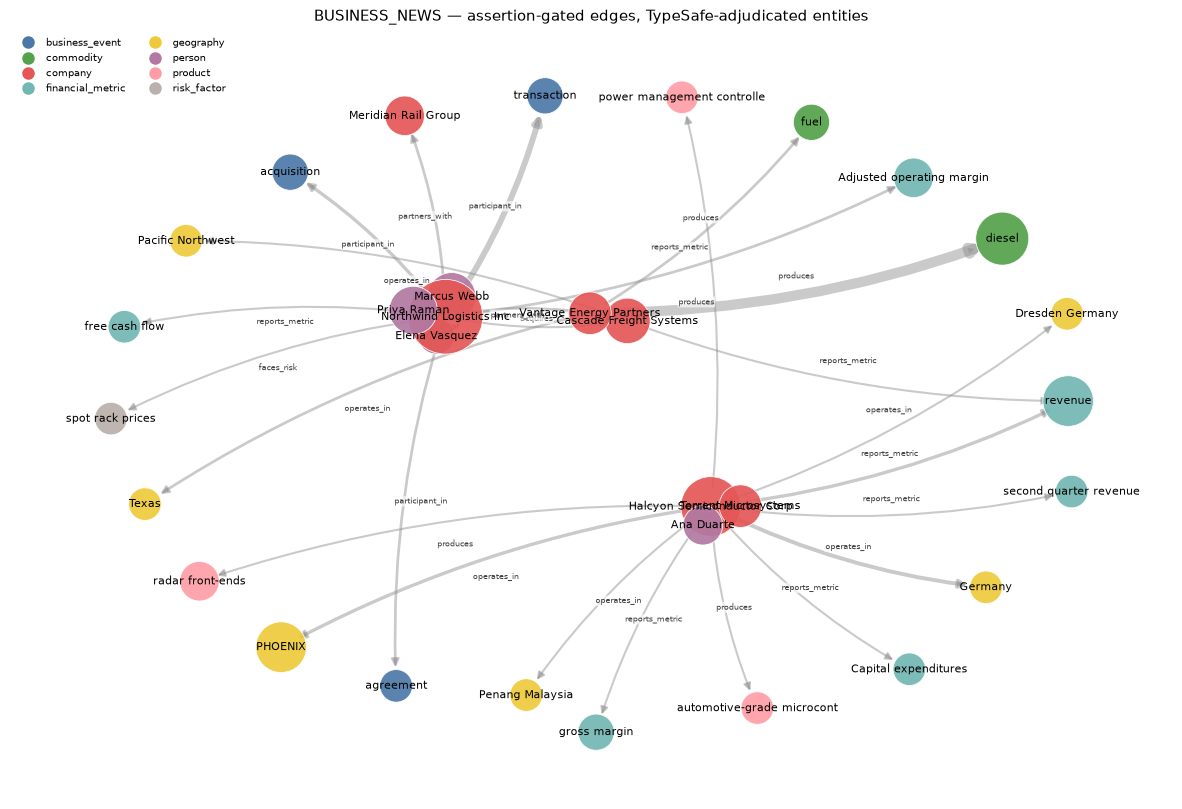

In [44]:
kgx.draw(kg_final, min_support=2, figsize=(15, 10),
         title="BUSINESS_NEWS — assertion-gated edges, TypeSafe-adjudicated entities")
plt.show()

---

## 5. What it cost

Tokens and wall time, separated into what **this run** billed and what the calls **were** when they were
first made — so a fully-cached re-run reports real latency instead of zeros. The same accounting
`kgx.llm.ClaudeCLI` does for the `claude` CLI.

In [45]:
stats = ts.stats()
display(pd.Series(stats).to_frame("value"))

n_req = stats["requests_live"] + stats["requests_cached"]
print(f"\n{stats['questions']} questions across {n_req} requests "
      f"({stats['questions_per_request']} per request)")
print(f"{stats['input_tokens_observed'] / max(1, stats['questions']):.0f} input tokens per question")
print(f"{stats['ms_per_request_observed']:.0f} ms per request (as observed, live or replayed)")
print(f"\nGLiNER2.5 extraction of the same corpus: {gliner_s:.1f}s, local, no key")

,value
requests_live,0.0
requests_cached,159.0
questions,982.0
questions_per_request,6.2
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,236038.0
output_tokens_observed,44269.0
ms_spent,0.0
ms_per_request_observed,174.0



982 questions across 159 requests (6.2 per request)
240 input tokens per question
174 ms per request (as observed, live or replayed)

GLiNER2.5 extraction of the same corpus: 14.1s, local, no key


The comparison that matters is not TypeSafe against GLiNER — they are not doing the same job. It is the
**question batching**: every one of the edge-gating requests carried up to 24 questions over one shared
document, and the document's tokens were paid once per request rather than once per question. Run the same
work one question at a time and the input-token count is the thing that moves.

In [46]:
# The counterfactual, computed rather than asserted: what the same questions would
# have cost one per request. Only the *document* text is counted on both sides --
# the instructions cost the same either way, so they cancel.
doc_tokens = {g.doc_id: len(g.text) / 4 for g in graphs}     # ~4 chars/token, order of magnitude

batched = sum(doc_tokens[g.doc_id] * math.ceil(len([e for e in g.edges if not e.derived])
                                               / EDGES_PER_REQUEST)
              for g in graphs)
unbatched = 2 * sum(doc_tokens[j.doc_id] for j in judgments)   # 2 questions, 1 request each

print(f"{2 * len(judgments)} edge questions over {len(graphs)} documents")
print(f"  batched, {EDGES_PER_REQUEST} edges per request:  ~{batched:>9,.0f} "
      f"input tokens of document text")
print(f"  one question per request:        ~{unbatched:>9,.0f}")
print(f"  ratio:                            {unbatched / max(1, batched):>9.1f}x")
print(f"\nmeasured input tokens, every request in this notebook: "
      f"{stats['input_tokens_observed']:,}")

340 edge questions over 10 documents
  batched, 12 edges per request:  ~    6,818 input tokens of document text
  one question per request:        ~  128,312
  ratio:                                 18.8x

measured input tokens, every request in this notebook: 236,038


---

## 6. Findings

*Measured on this repo's corpus, not asserted. Every number above is reproducible from the cached
responses in `output/typesafe_cache/`.*

In [47]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
print(f"corpus                   {len(DOCUMENTS)} documents, {len(mentions)} mentions, "
      f"{len(edges)} edges")
print()
print("EXTRACTION")
print(f"  modality traps caught  {caught_v1}/{len(MODALITY_TRAPS)} with the first `factual` wording, "
      f"{caught}/{len(MODALITY_TRAPS)} with the current one")
print(f"  controls preserved     {int(controls['asserted'].sum())}/{len(controls)}")
print(f"  edges kept by gate     {int(J['keep'].sum())}/{len(J)}")
for name, s in scores.items():
    print(f"  {name:<25} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
print()
print("RESOLUTION")
print(f"  baseline               P {base['precision']:.4f}  R {base['recall']:.4f}  "
      f"F1 {base['f1']:.4f}")
_m = kgx.bcubed(merged, GOLD)
print(f"  + review band          P {_m['precision']:.4f}  R {_m['recall']:.4f}  "
      f"F1 {_m['f1']:.4f}")
_r = kgx.bcubed(recovered, GOLD)
print(f"  + cross-type recovery  P {_r['precision']:.4f}  R {_r['recall']:.4f}  "
      f"F1 {_r['f1']:.4f}   (pairs hand-fed)")
_a = kgx.bcubed(res_argmax.mention_to_canon, GOLD)
print(f"  + re-typed, argmax     P {_a['precision']:.4f}  R {_a['recall']:.4f}  F1 {_a['f1']:.4f}")
_s = kgx.bcubed(soft_map, GOLD)
print(f"  + re-typed, soft       P {_s['precision']:.4f}  R {_s['recall']:.4f}  F1 {_s['f1']:.4f}"
      f"   ({len(clones)} clones, pipeline unchanged)")
print(f"  blocking proposed      {blocking['pair_completeness']:.4f} of gold-same pairs")
print()
print("MUST-NOT-MERGE (shopping)")
print(f"  resolver               false merges {len(resolver_merged)}/{shop_gold.count('different')}")
for name, frame in [("adjudicator, plain", P), ("adjudicator, guided", G)]:
    fm = int(((frame["outcome"] == "merge") & (frame["gold"] == "different")).sum())
    fr = int(((frame["outcome"] == "reject") & (frame["gold"] == "same")).sum())
    print(f"  {name:<22} false merges {fm}/{shop_gold.count('different')}   "
          f"false rejects {fr}/{shop_gold.count('same')}")
print()
print("COST")
print(f"  requests               {stats['requests_live']} live, {stats['requests_cached']} replayed")
print(f"  questions              {stats['questions']} "
      f"({stats['questions_per_request']} per request)")
print(f"  input tokens observed  {stats['input_tokens_observed']:,}")
print("=" * 78)

                                   SUMMARY                                    
corpus                   10 documents, 214 mentions, 170 edges

EXTRACTION
  modality traps caught  8/11 with the first `factual` wording, 11/11 with the current one
  controls preserved     5/5
  edges kept by gate     114/170
  GLiNER2.5, ungated        P 0.279  R 0.404  F1 0.330
  + TypeSafe assertion gate P 0.404  R 0.404  F1 0.404

RESOLUTION
  baseline               P 1.0000  R 0.8972  F1 0.9458
  + review band          P 1.0000  R 0.8972  F1 0.9458
  + cross-type recovery  P 1.0000  R 1.0000  F1 1.0000   (pairs hand-fed)
  + re-typed, argmax     P 1.0000  R 0.9142  F1 0.9552
  + re-typed, soft       P 1.0000  R 1.0000  F1 1.0000   (17 clones, pipeline unchanged)
  blocking proposed      0.8791 of gold-same pairs

MUST-NOT-MERGE (shopping)
  resolver               false merges 3/11
  adjudicator, plain     false merges 0/11   false rejects 0/6
  adjudicator, guided    false merges 0/11   false rejects 

### The assertion gate is the win, and it costs no recall

Gating on `supported >= 0.5 and status == 'asserted'` drops **56 of 170 edges** and takes triple precision
from **0.279 to 0.404** — with **recall unchanged at 0.404**. Not approximately: identical. Of the 56 edges
removed, not one was a gold triple.

The two failure columns say why that is possible. 31 of the 56 were edges the document never connected at
all; 25 were edges it connected and then hedged or denied. Both are invisible to a span model for the same
reason — **span confidence is about the decoding, not about the claim** — and the §2.3 scatter is the
compact version: GLiNER's confidence runs the full width on both the kept and the dropped edges.

### For the decision the two edge questions are nearly redundant; for the diagnosis they are not

`status` alone (F1 0.396) and `supported` alone (0.376 at a 0.8 threshold, 0.396 at 0.95) each recover
most of the gain, and together they reach 0.409. The 31/25 split is real — they catch different edges — but the signals are correlated, so a
boolean collapsed from either would score about the same. What it would lose is the *reason* for every drop.
That is the practical case for storing raw judgments rather than a verdict, and §4 acts on it.

### A `Noul` that hides a second reading resolves it silently — and naming the reading fixes it

The first wording of the `factual` Noul caught **8 of 11** planted modality traps; the `Choice` over four
statuses, asked in the same request, called all eleven non-asserted. Every miss was a **denial** —
*"Management has no plans to divest…"* — where the sentence states a perfectly true fact about an intention
*not* to act. The question had two readings for a denial and the model took the other one, at 0.66, 0.71 and
0.74: **not** near 0.5.

That is the part worth carrying away. A Noul near 0.5 means *equally likely yes or no*, so ambiguity in the
**question** does not surface as an uncertain answer — it surfaces as a confident answer to the reading you
did not mean. Rewording the question to name the thing being judged and the trap itself (*a sentence saying
something will NOT happen does not make it a fact*) took the same model on the same sentences to **11 of
11**, with the controls still 5 of 5 and the gap between the trap and control distributions opening from
0.07 to 0.63. **Keep the distinction in the answer type, or state it in the question. Never fold it into a
probability and hope.**

### Controls are what make a trap count mean anything

Without the five control sentences a detector that answers *not factual* to everything scores 11/11. With
them, both wordings have to separate two distributions, and the numbers in §2.2 show whether they do.

### A perfect judge on the wrong queue is worth exactly nothing

Adjudicating the review band made **28 merges, every one correct, none contradicting the gold labels** — and
moved B-cubed by **zero to four decimal places** (P 1.0000, R 0.8972, F1 0.9458 before and after), while the
clustering genuinely changed from 109 to 104 clusters.

The §3.4 diagnostic gives the reason, and it is two things stacked. All 28 gold-labelled merges were **already
in one cluster by transitivity** before the adjudicator was asked. The 10 merges that did change clusters —
`Phoenix, Arizona`/`Phoenix`, `Telematics unit`/`Telematics`, `adjusted operating margin`/`operating margin` —
are on mentions **outside `ALIAS_GROUPS`**, which B-cubed cannot see.

This sharpens notebook 05's conclusion rather than repeating it. There, the wins came from candidate
generation rather than scoring. Here the judge scored *perfectly* and still bought nothing, because every
pair it was permitted to see was either redundant or unlabelled.

### The missing pairs were a type disagreement, not a string-similarity failure

41 gold-same pairs were still split, and **none of them had ever been proposed**. Their content is the
diagnosis: `HLCN` against every spelling of Halcyon, and `Torrent Microsystems` against **itself**.

Two identical strings in different clusters is not a scoring problem. The extractor types `HLCN` as
**`security`** — a ticker symbol, which it is — and `Halcyon Semiconductor` as **`company`**. It types the
string `Torrent Microsystems` as `company` in one document and `security` in another. Blocking is
type-scoped, so none of these pairs is ever a candidate, whatever the strings say, and the scoring function
never runs on the most obvious merge in the corpus.

This is notebook 09's gazetteer finding in a second location: *both sides reasonably disagreed about whether
an airport is a place.* Here they reasonably disagree about whether a ticker is a company or an instrument.
**A type constraint anywhere in candidate generation needs its cost measured, not assumed.**

### Handed the pairs blocking refused, the same judge reaches B-cubed 1.000

**8 requests.** 7 merges, 1 review, 0 contradicting the gold labels, and B-cubed F1 **0.9458 → 1.0000** at
precision 1.0000 — which is where notebook 05's best configurations (Splink, and Claude adjudication) also
land, reached from the opposite direction and with a diagnosis attached.

The diagnostic Nouls are what make it legible rather than lucky, and §3.6 reads four of them. Two pairs
needed merging for two unrelated reasons — identical strings the extractor typed two ways, and a ticker
symbol no string metric can expand — and the raw judgments say which is which. The one `review` outcome,
`HLCN`/`Halcyon` at level 1.49 with `same_context` 0.22, is the adjudicator hedging on the least contextual
pair, and transitivity recovers it anyway through the others. §3.7 then reaches the same 1.000 with the
pipeline intact, by fixing the cause.

### The type wall comes down when blocking reads the distribution instead of the label

Re-typing every mention against the ontology by *referent* agrees with GLiNER on 192 of 214 and moves
recall 0.897 → 0.914 — but leaves `HLCN` as `security`, at 0.56 with `company` at 0.41, because the
ontology says a ticker *is* a security and the model reports that ambiguity faithfully. Reading the
distribution instead of the argmax — a clone of each ambiguous mention in every type block with ≥ 25% of
the mass, 17 clones in all — takes the **unchanged resolver to B-cubed 1.000 at precision 1.000**, with no
pair hand-fed and no scoring rule touched.

That closes §3.5's loop at the cause rather than the symptom, and it is the same lesson as the d06
`Score`: a `Choice` at 0.56/0.41 is not a label with a wobble, it is a request to be allowed both
readings. Type-scoped blocking that reads the label makes a wall of it. The 10 requests it cost are the
cheapest thing in the notebook.

### It refuses too — and the ontology's guideline is what makes it refuse with confidence

On the shopping corpus's must-not-merge pairs the repo's resolver merges three of twelve. The adjudicator
merges **none** of the eleven testable ones, under either wording, while merging or holding every one of
the six must-merge pairs: zero false merges, zero false rejects. Asked plainly it hedges once
(`Aurora 14` / `Aurora 14 Pro` at 0.67, `review`); with the shopping ontology's own product definition in
the instructions all three resolver over-merges come back `reject` at ≤ 0.06.

The guideline is not free: two cross-type must-merge pairs lose confidence and `Tidewater Supply` /
`Tidewater` moves from `merge` to `review`. Nothing becomes wrong; something becomes a curator's job. A
domain rule in the question sharpens the side it was written for and costs a little on the side it was
not — a trade worth making when the alternative is a string metric that cannot see the rule at all.

### `pair_completeness` is not a ceiling on B-cubed recall

0.8791 against a baseline recall of 0.8972, and a recovered recall of 1.0000. The two get quoted together as
if the first bounded the second. It does not, because clustering is transitive and unites pairs blocking
never proposed. What it bounds is **what an adjudicator can be asked about** — which is the real constraint,
and precisely the one the review band ran into.

### Aggregating a judgment onto a canonical edge must rank on assertion, not support

The first version of §4 kept the highest-`supported` judgment per canonical edge and lost three edges,
including the headline acquisition. `acquires(Northwind, Cascade)` is hedged in d01 — *"the proposed
acquisition, if approved by the Surface Transportation Board"* — at `supported` 0.99, and asserted in a later
document at a lower one, so ranking on support alone picks the hedge.

The repo already had the right rule written down for a different field: *an edge stated clearly once and
hedged twice is still stated clearly once.* The §4 equivalence check is three lines and is the only reason
this was caught instead of shipped.

### A `Score` is an expected value, and sometimes the expected value is a level nobody believes

The d06 probe in §1 put 0.70 on *completed* and 0.29 on *speculative*, and reported a score of 1.41 — a
level with 0.01 of the mass, at `confidence` 0.12. Nothing went wrong; the document really does report a
completed inquiry and a second-hand price war, and the model said so. What it means in practice is that
`round(score)` is only a decision rule when `confidence` says the distribution has one mode. The
entity-alignment cookbook's `round(score)` works in §3 because the pair verdicts are unimodal; the
`confidence` field is there to tell you when they are not.

### Batching is worth ~19x on input tokens, and it is a design decision rather than a flag

Edge gating was 340 questions in 35 requests, because one request carries up to a dozen edges over one
shared document. One question per request would re-send each document 34 times: ~128k tokens of document
text against ~6.8k, a **18.8x** difference on that component.

That saving comes from what goes in the state, not from a batch endpoint. It also constrains how the
questions are written: every question in a request sees the same state and question ids are never sent to
the model, so each question has to name its own edge in its instructions.

### Where this sits next to the other two extractors

Not a replacement for either. GLiNER2.5 produced the 170 candidate edges in ~13 s on a CPU with no key, and
System One cannot do that — it has no spans and nothing to anchor. What it did was answer several hundred
questions about those candidates that neither a span model nor a threshold could answer, in typed form, at
under a fifth of a second per request.

**Candidate generation and judgment are different jobs.** Both findings above are the same shape from
opposite ends: the gate worked because the extractor had already produced the candidates, and the
adjudicator was useless until something produced the candidates it needed. Extract locally and
exhaustively, judge selectively, and keep the judgments as data.